<a href="https://colab.research.google.com/github/spatel787/MiniProject2/blob/master/spate198_vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 2: Data Visualization

This section groups each project's commits by month, includes months with zero commits, creates the required plots, and identifies the longest inactivity gap.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import Image, display

In [2]:
df = pd.read_csv("spate198_project_summary.csv", sep=";")
df.columns = ["project", "commit", "author", "time", "message"]
df["datetime"] = pd.to_datetime(df["time"], unit="s", utc=True)
df["Month"] = df["datetime"].dt.tz_convert(None).dt.to_period("M")
projects = [
    "nansencenter_dapper",
    "quantumblacklabs_kedro-viz",
    "biod_sambamba",
    "hungpham2511_toppra",
    "bioimagesuiteweb_bisweb",
    "carloscinelli_sensemakr",
    "compphysvienna_n2p2",
    "shraddhabarke_probe",
    "openuc2_uc2-git",
    "fangq_mcx"
]
df.head()

,project,commit,author,time,message,datetime,Month
0,biod_sambamba,1eb3bb13a6923ed8873b86dcf3b323c7fd6d987f,Artem Tarasov <lomereiter@gmail.com>,1335621640,decompressing bgzf\n,2012-04-28 14:00:40+00:00,2012-04
1,biod_sambamba,d99d2fec9d833786b9e699a76027b375ed87c429,Artem Tarasov <lomereiter@gmail.com>,1335628908,fixes\n,2012-04-28 16:01:48+00:00,2012-04
2,biod_sambamba,81ba1511f39be7da9db35ea903289b3ce35f7f03,Artem Tarasov <lomereiter@gmail.com>,1335890609,parallel range transformer\n,2012-05-01 16:43:29+00:00,2012-05
3,biod_sambamba,273c8cf84970bf391661379ac25af4343691884f,Artem Tarasov <lomereiter@gmail.com>,1335891401,moved pool creation out of rangetransformer\n,2012-05-01 16:56:41+00:00,2012-05
4,biod_sambamba,b4fe27b0317008303615ac2121d5abc1cbcbdd28,Artem Tarasov <lomereiter@gmail.com>,1335891544,.\n,2012-05-01 16:59:04+00:00,2012-05


## Monthly time series, plots, and inactivity gaps

In [3]:
def make_monthly(project_df):
    counts = project_df.groupby("Month").size()
    months = pd.period_range(counts.index.min(), counts.index.max(), freq="M")
    counts = counts.reindex(months, fill_value=0)
    return pd.DataFrame({"Month": counts.index.astype(str), "#Commits": counts.values})

def find_gaps(monthly):
    gaps, start = [], None
    for row in monthly.itertuples(index=False):
        month = pd.Period(row.Month, freq="M")
        if row[1] == 0 and start is None:
            start = month
        elif row[1] > 0 and start is not None:
            end = month - 1
            gaps.append((str(start), str(end), end.ordinal - start.ordinal + 1))
            start = None
    return gaps

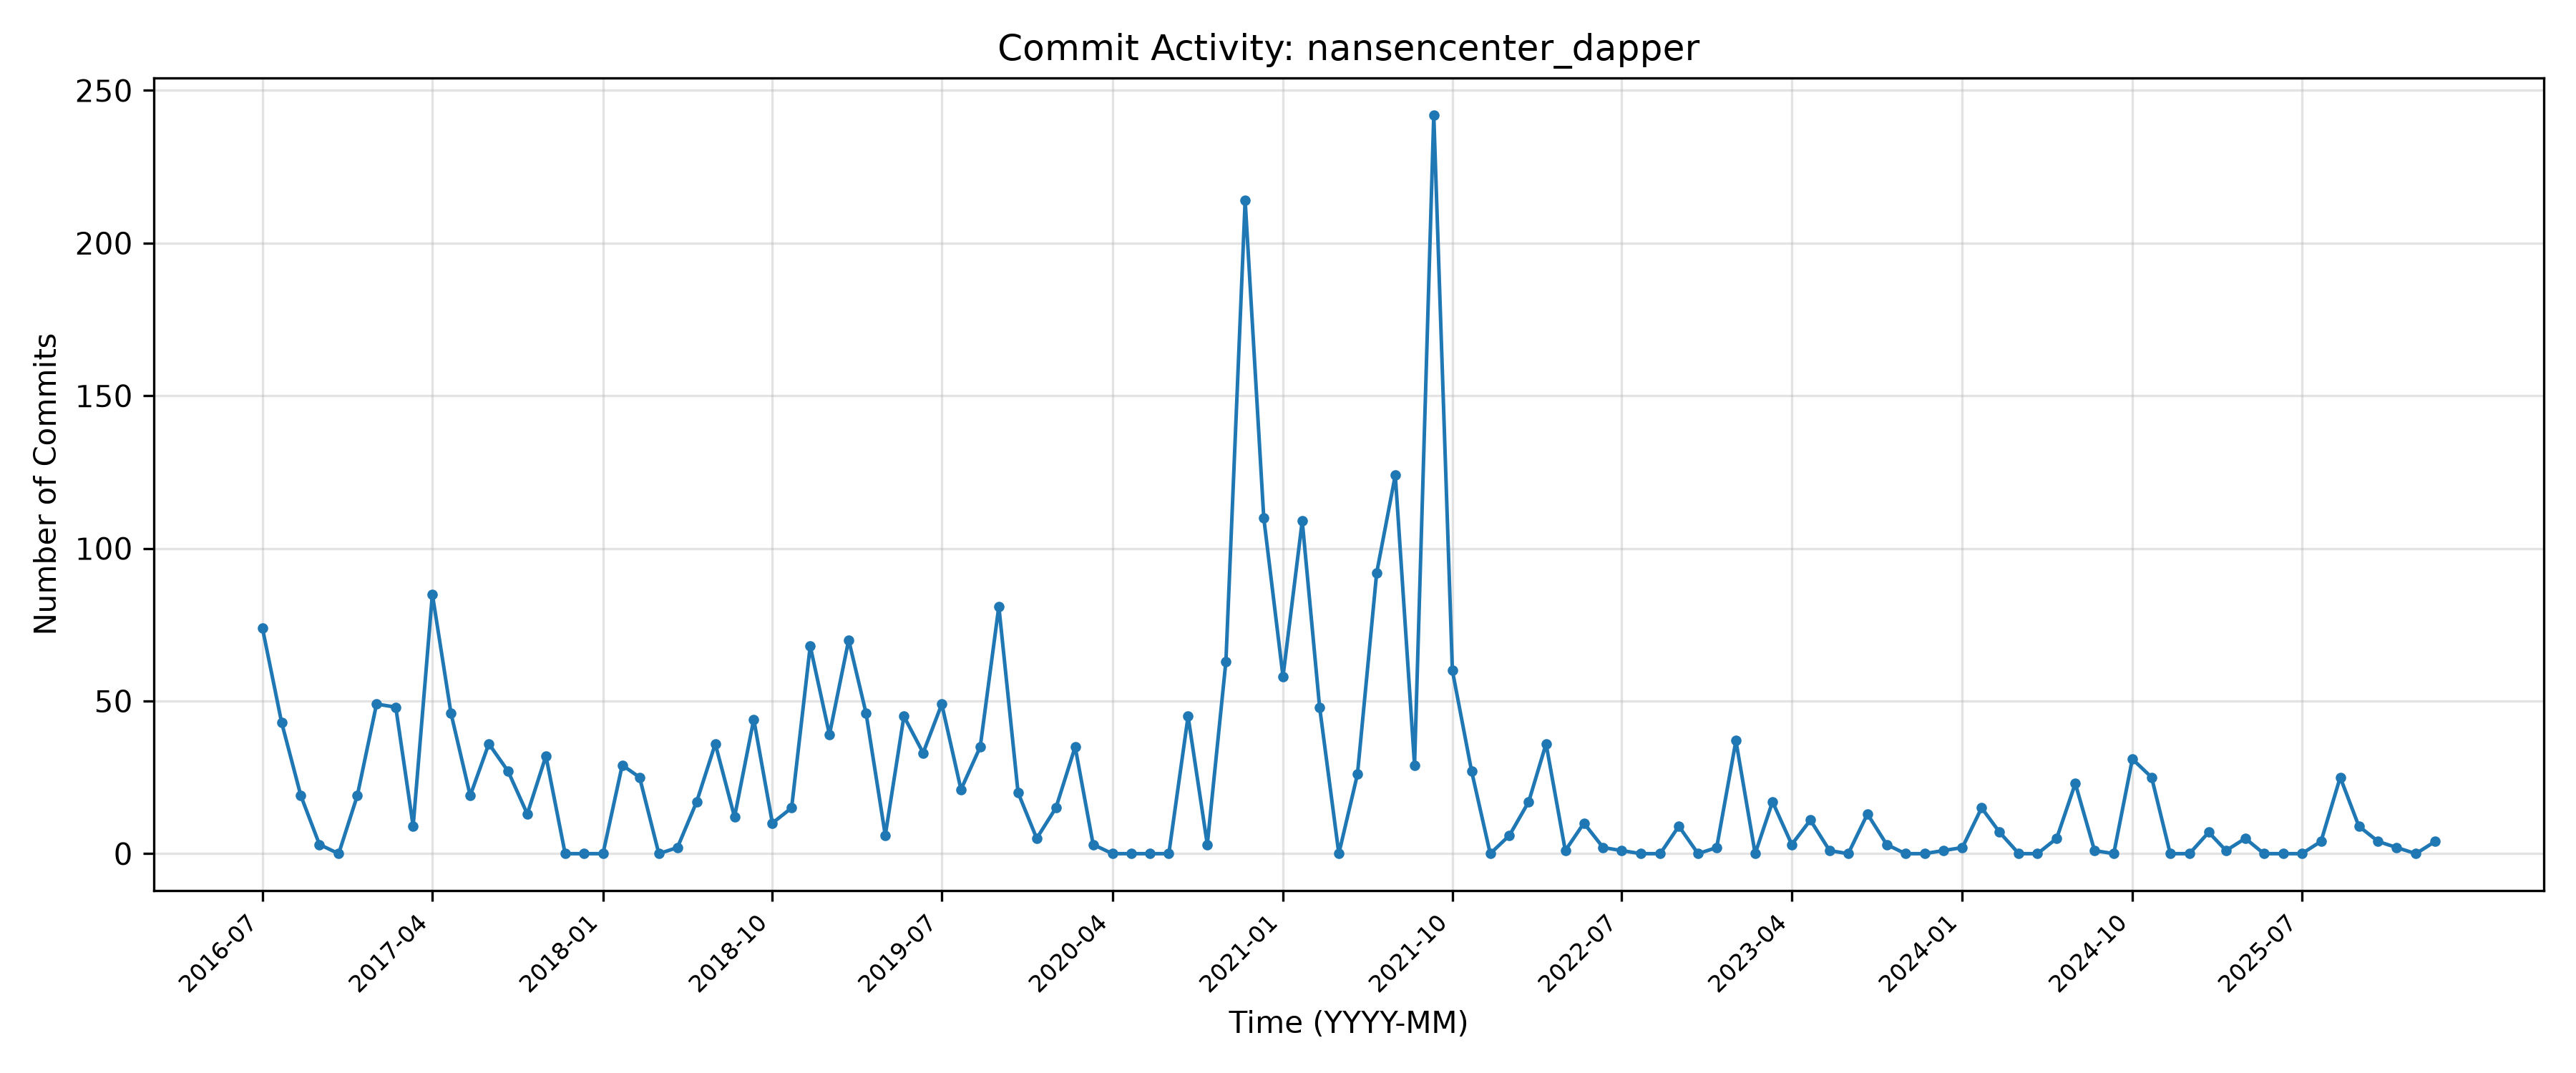

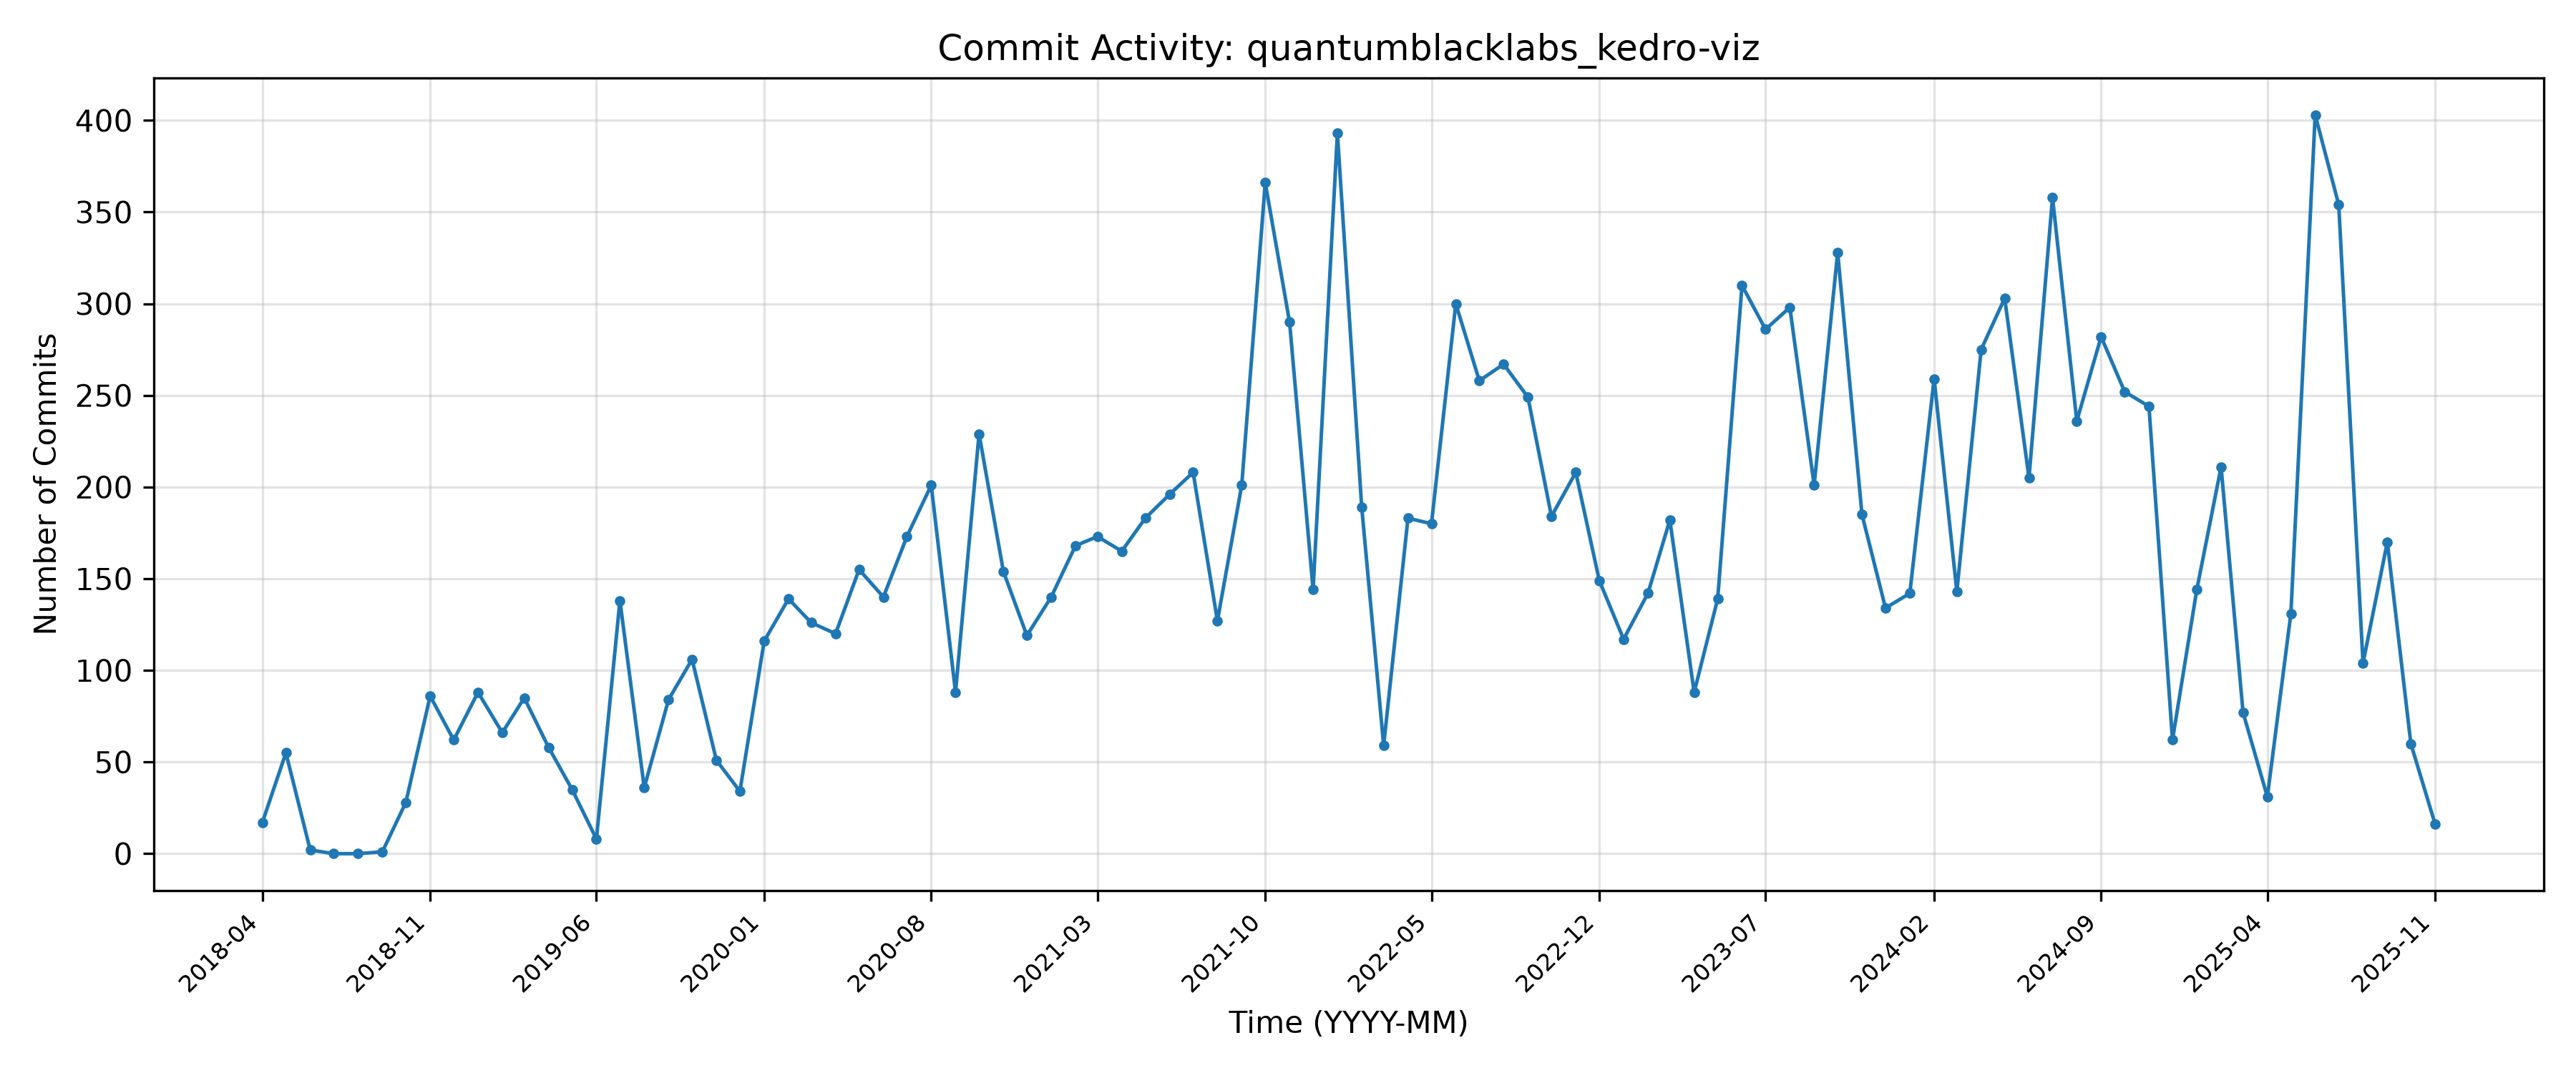

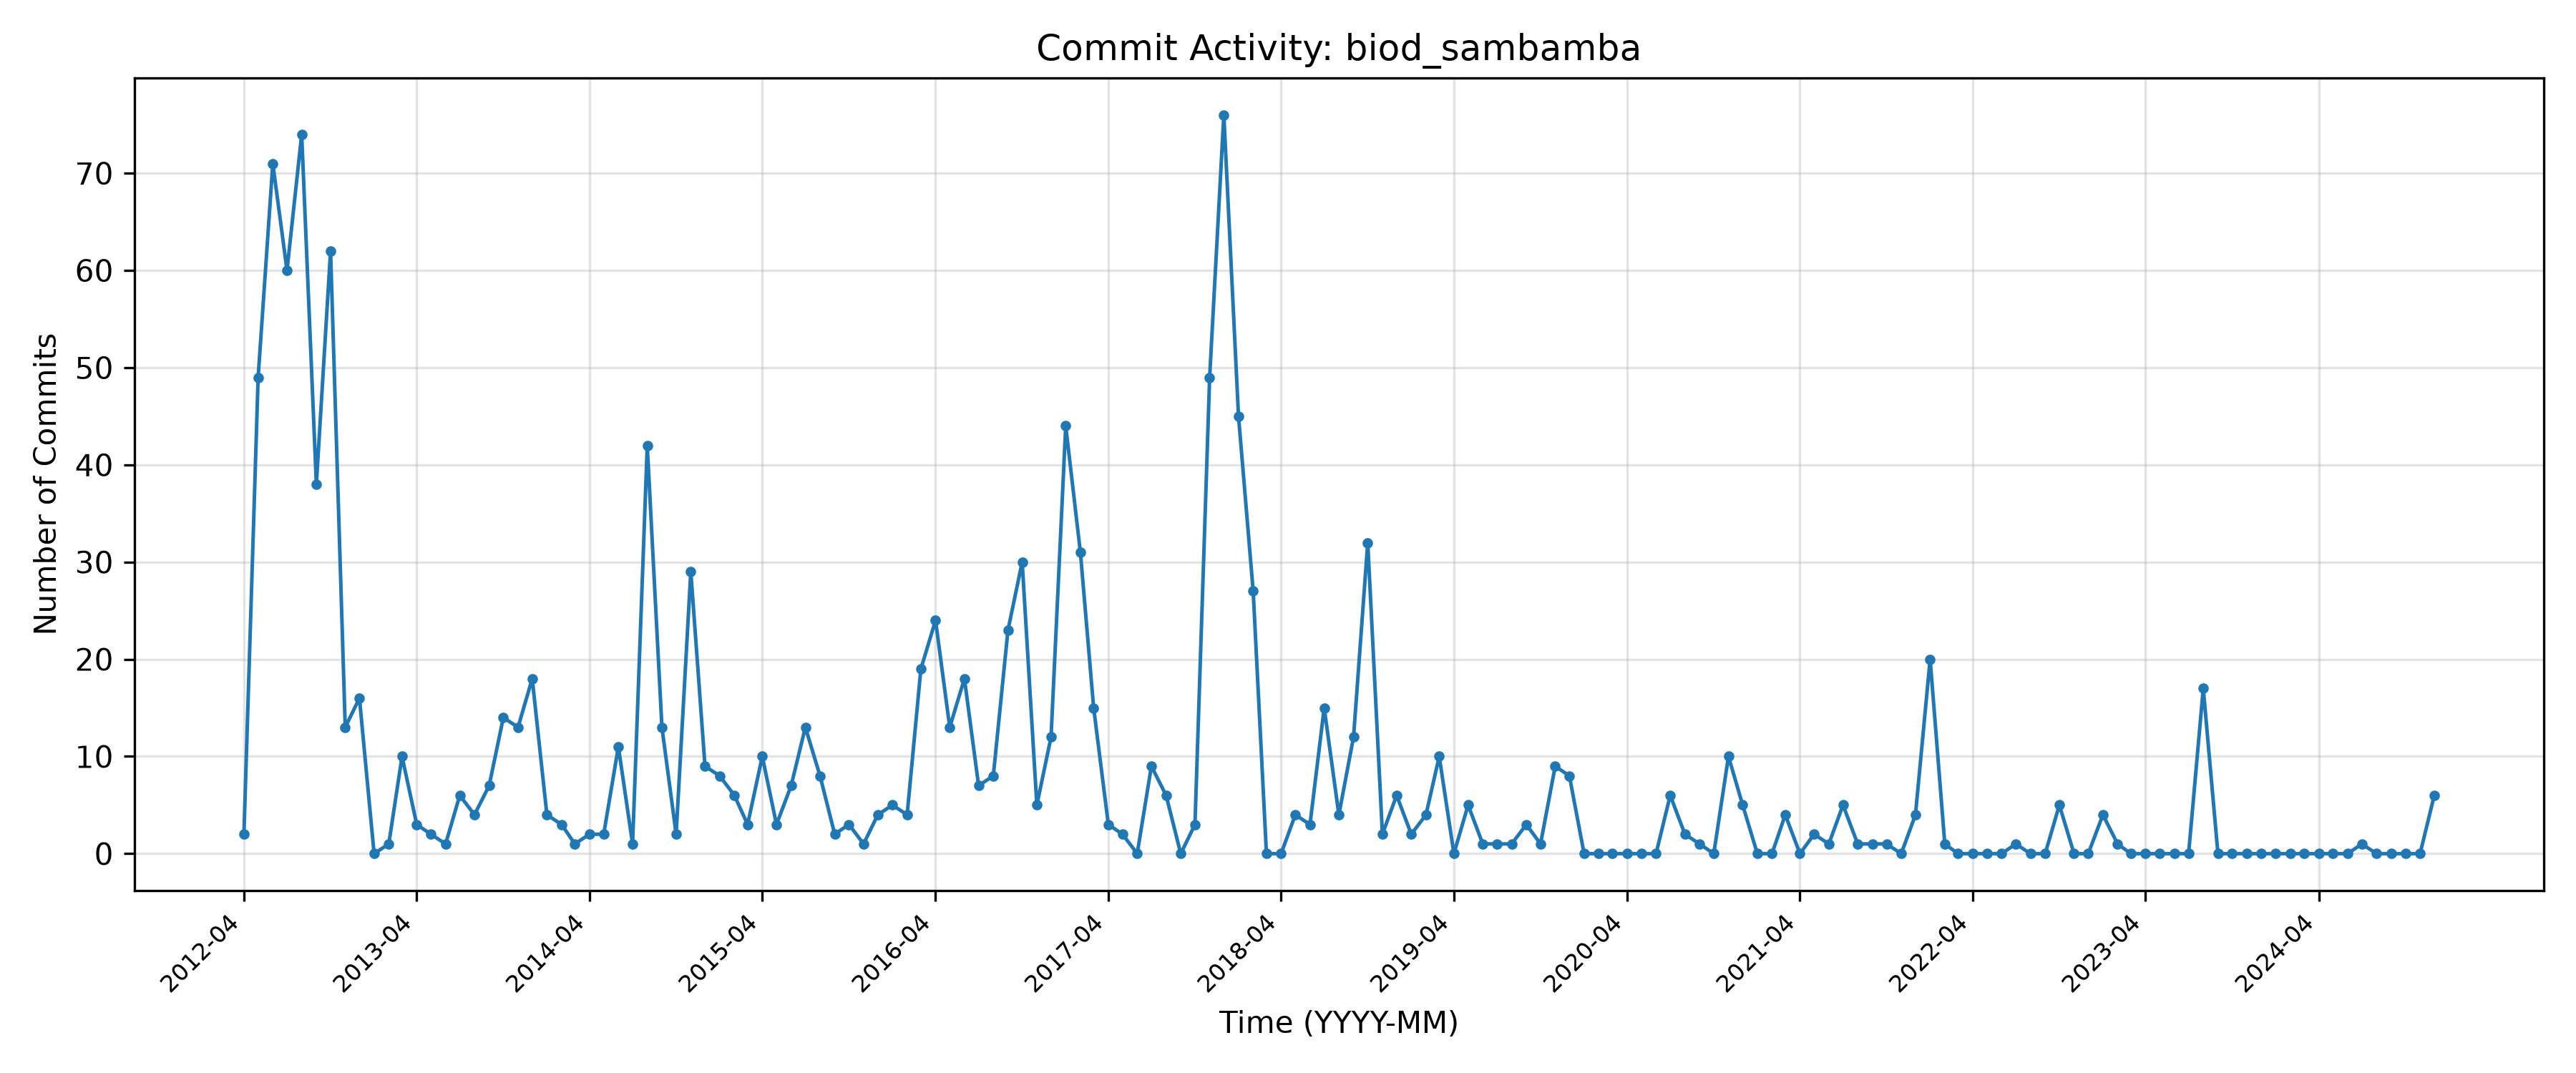

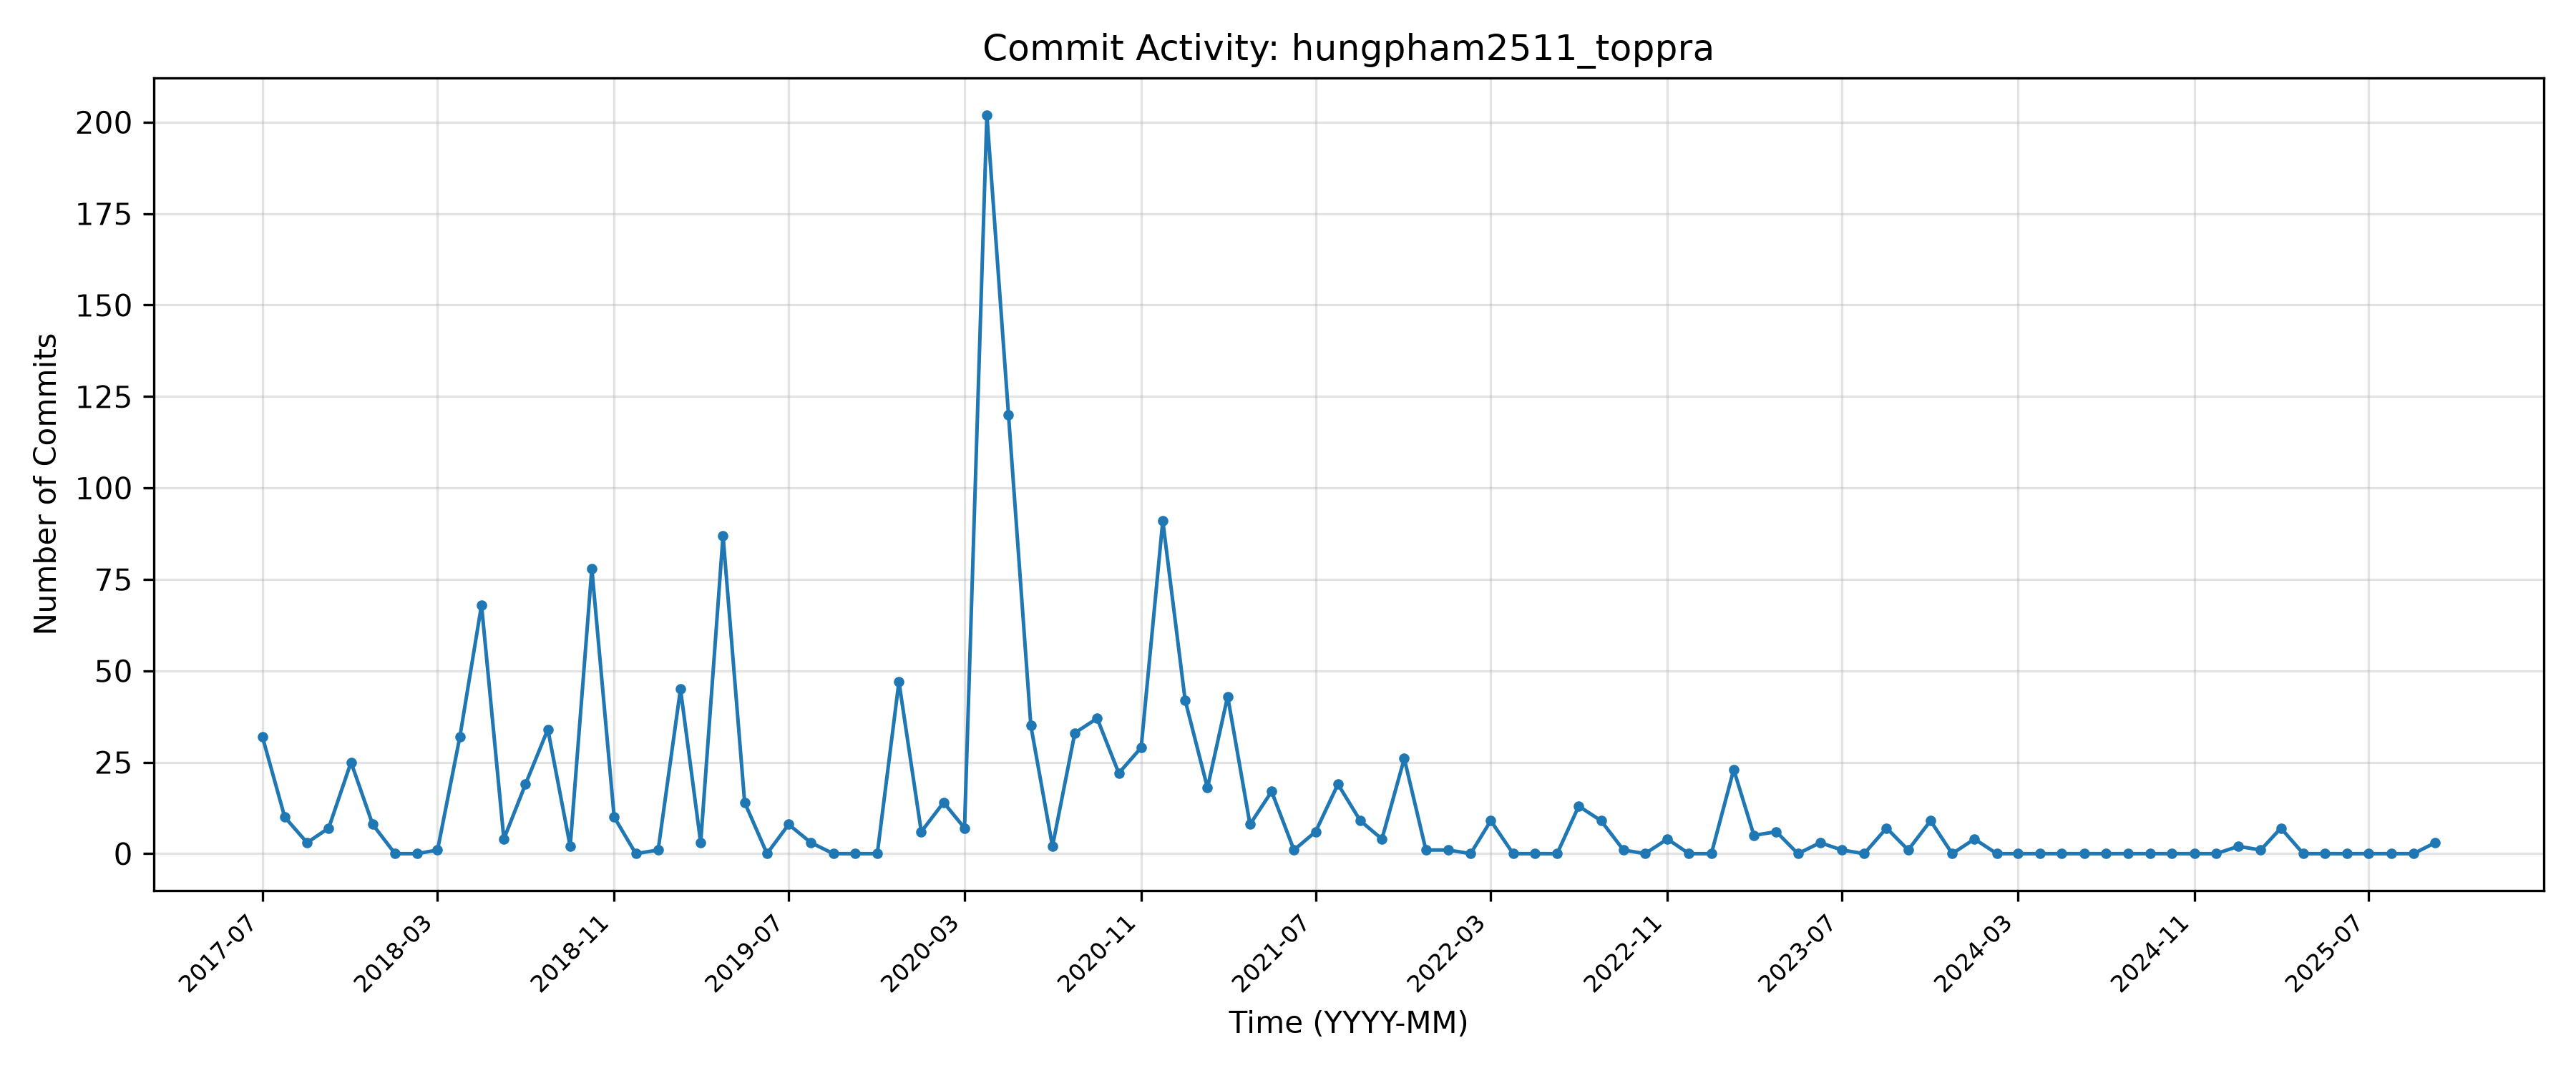

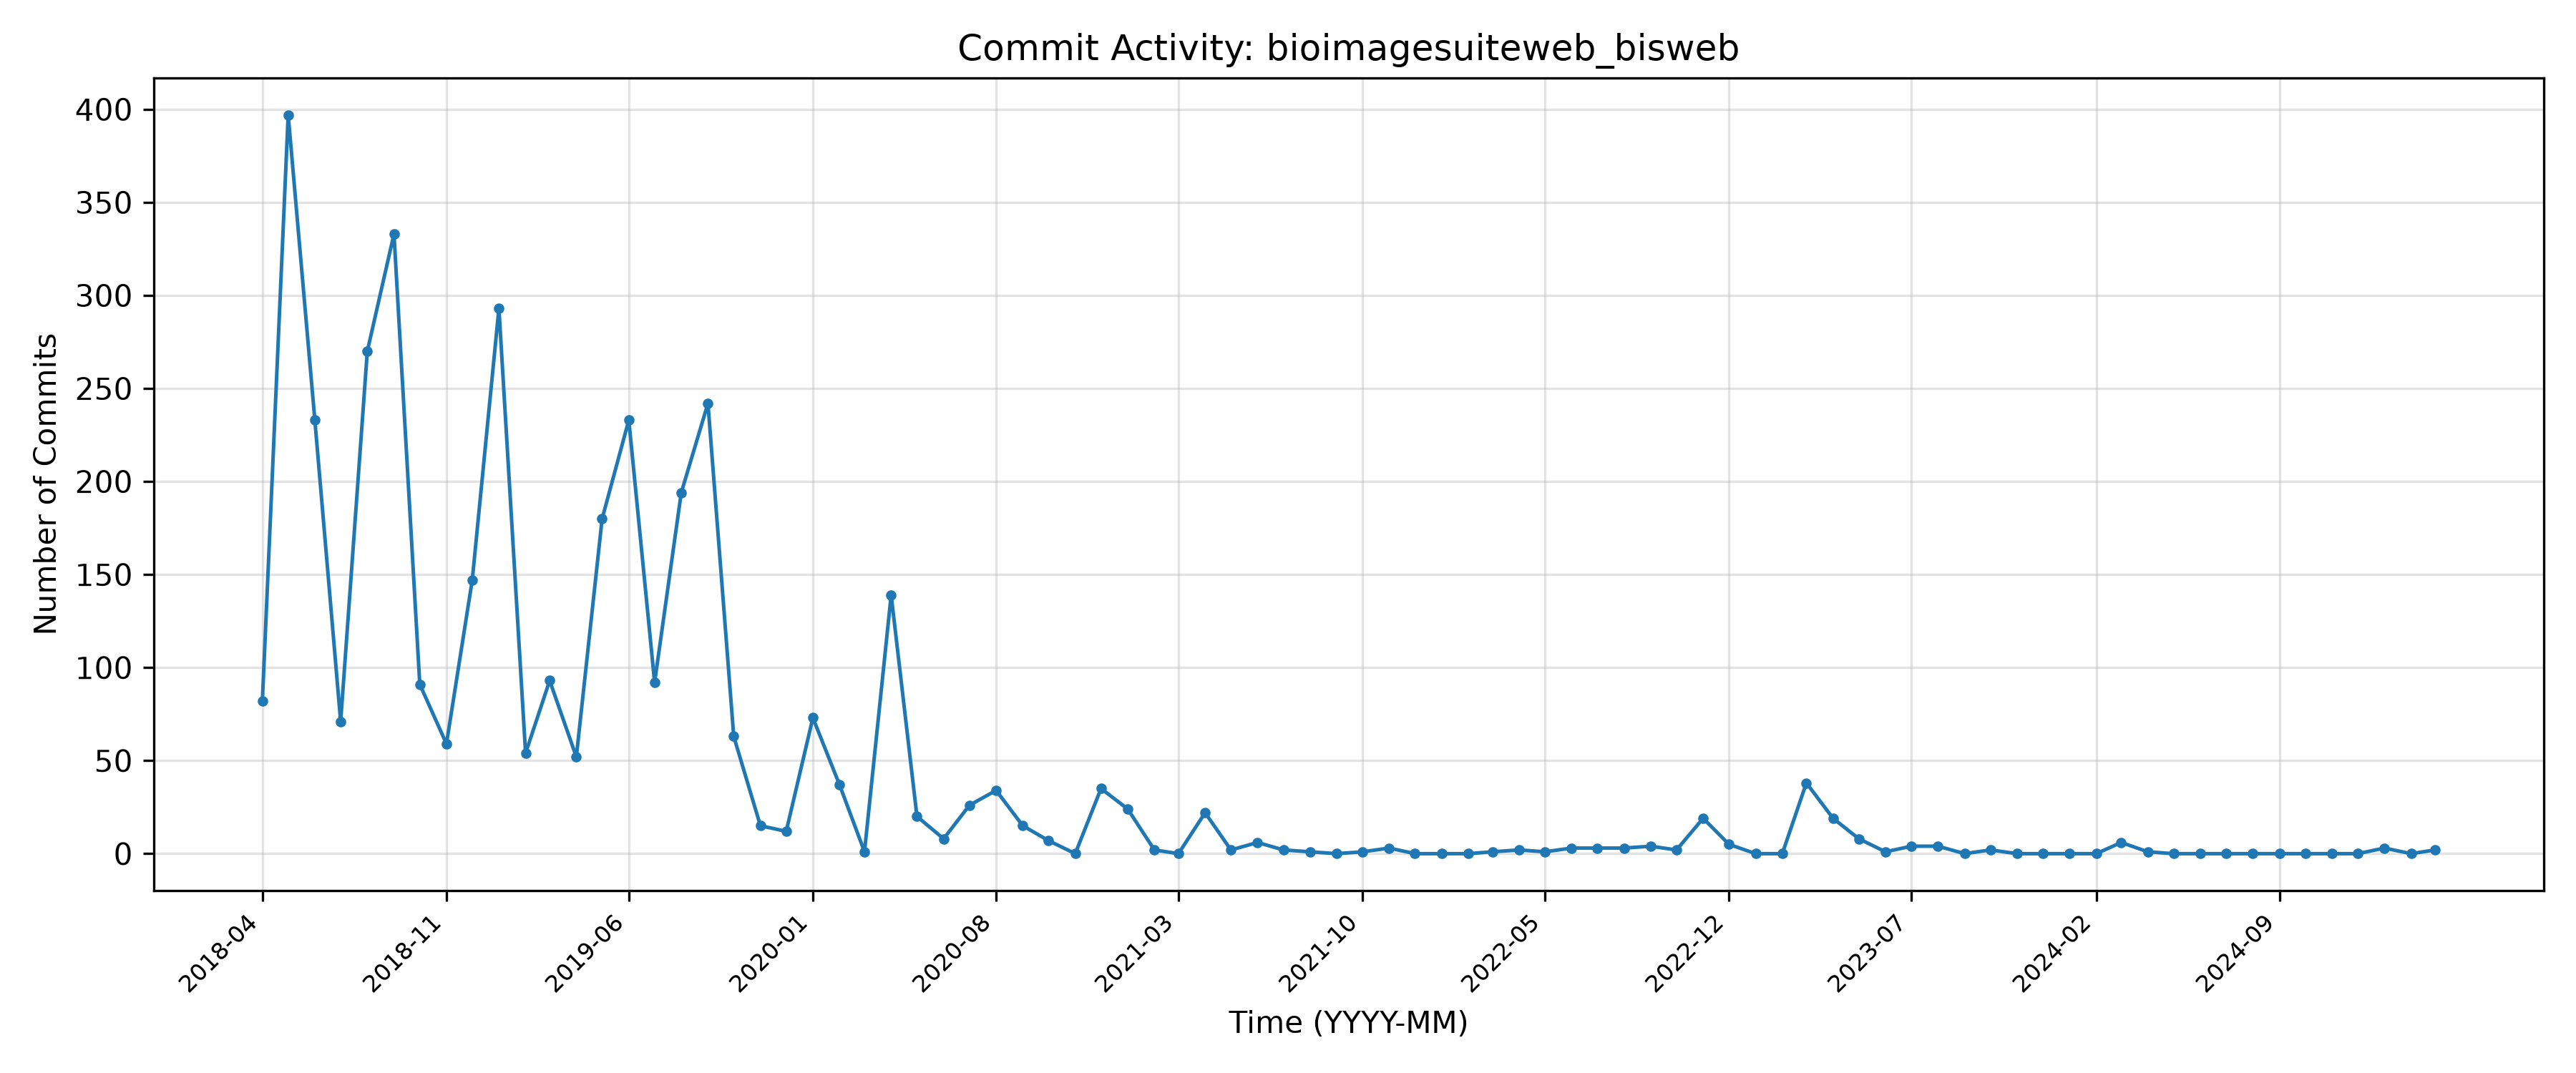

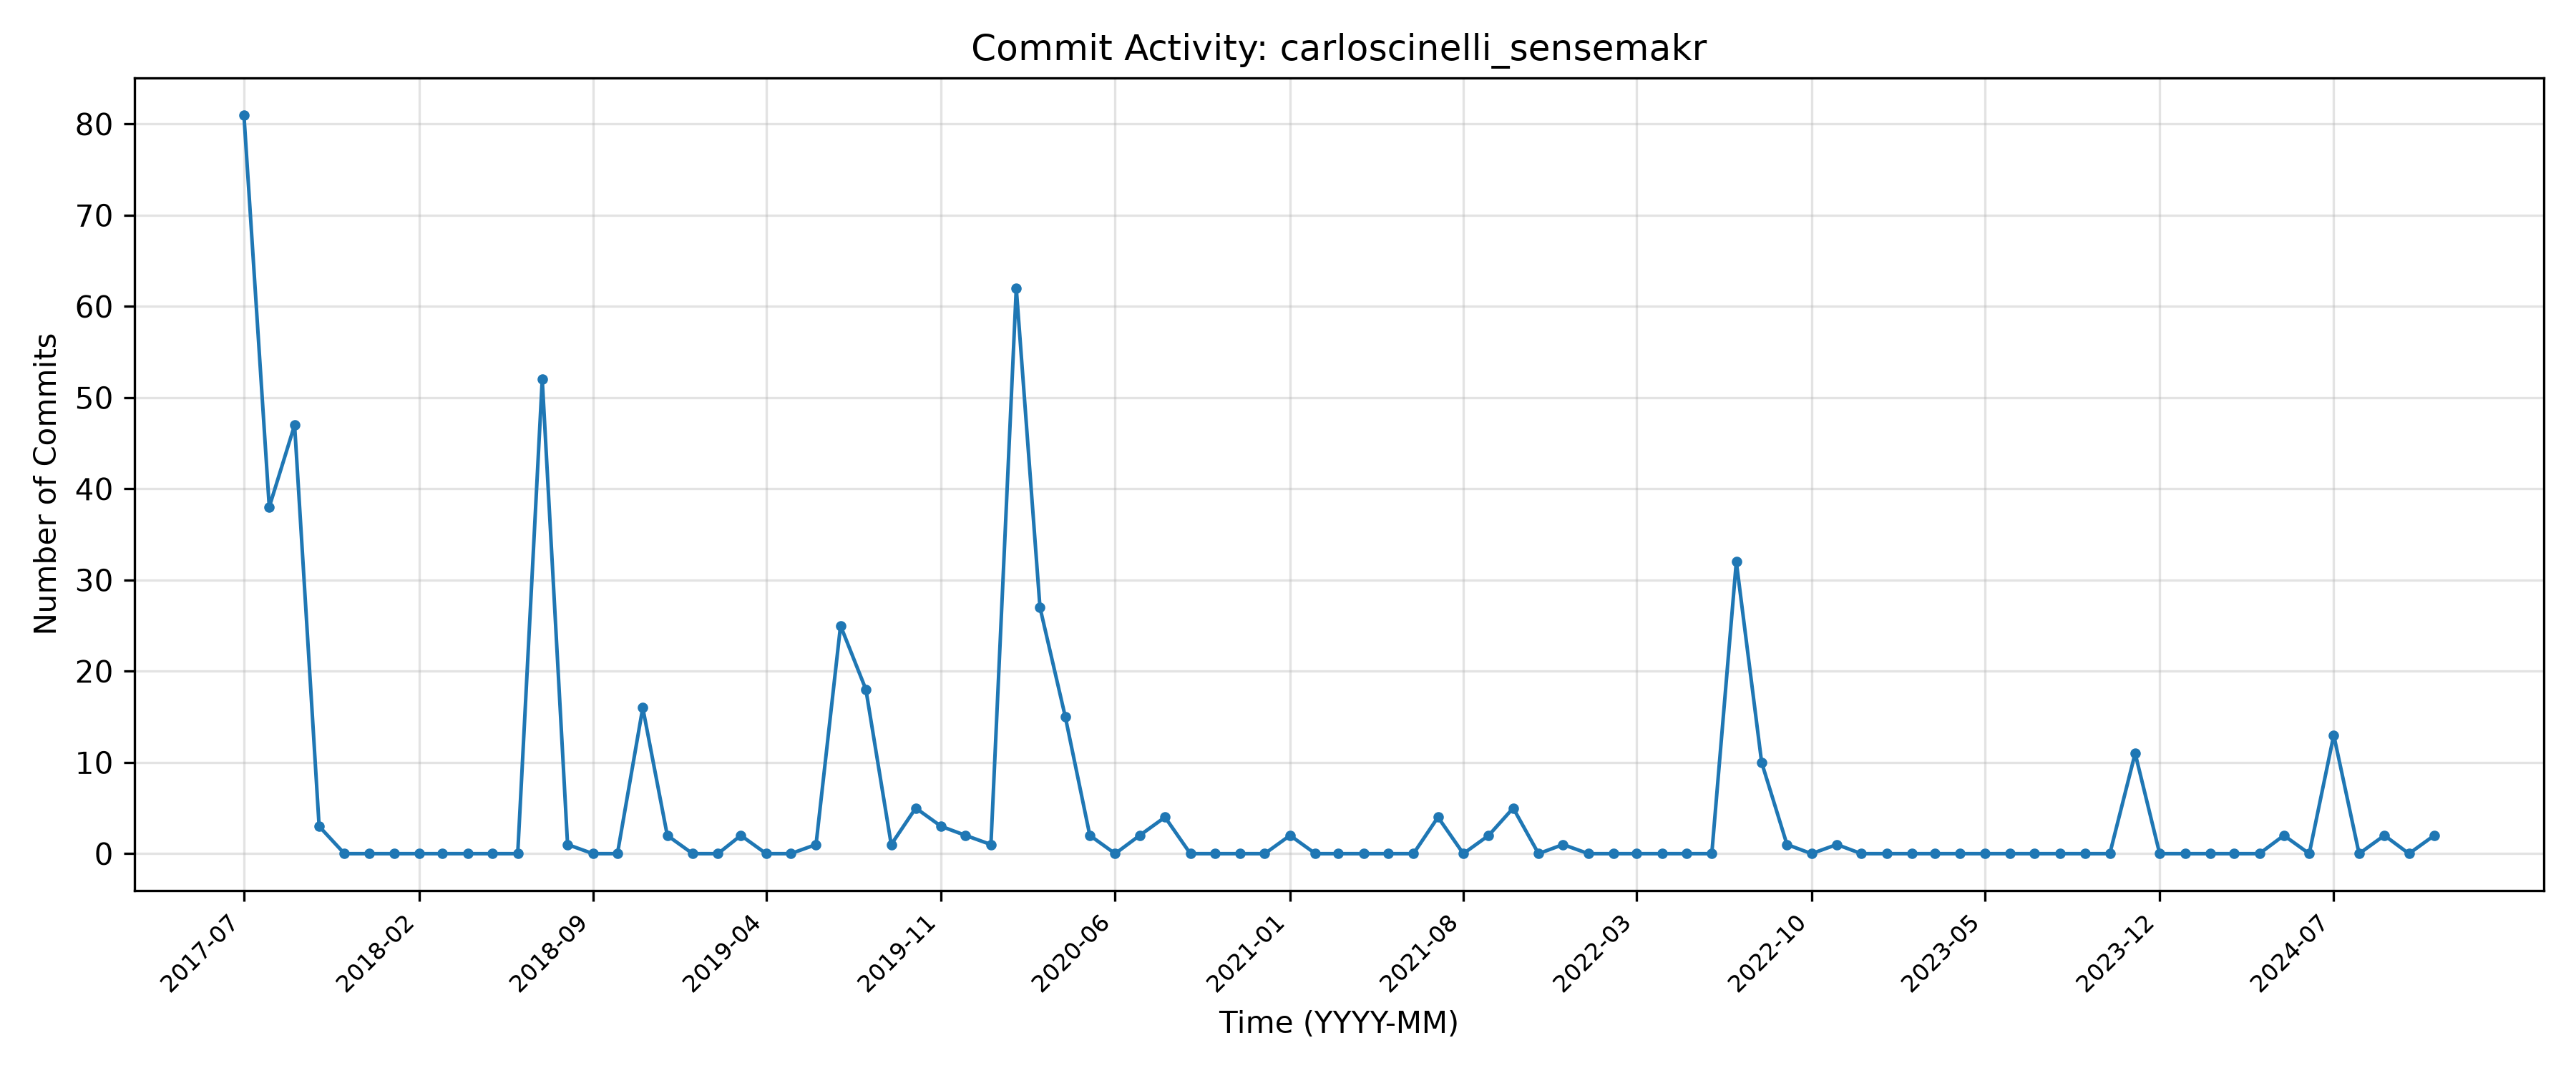

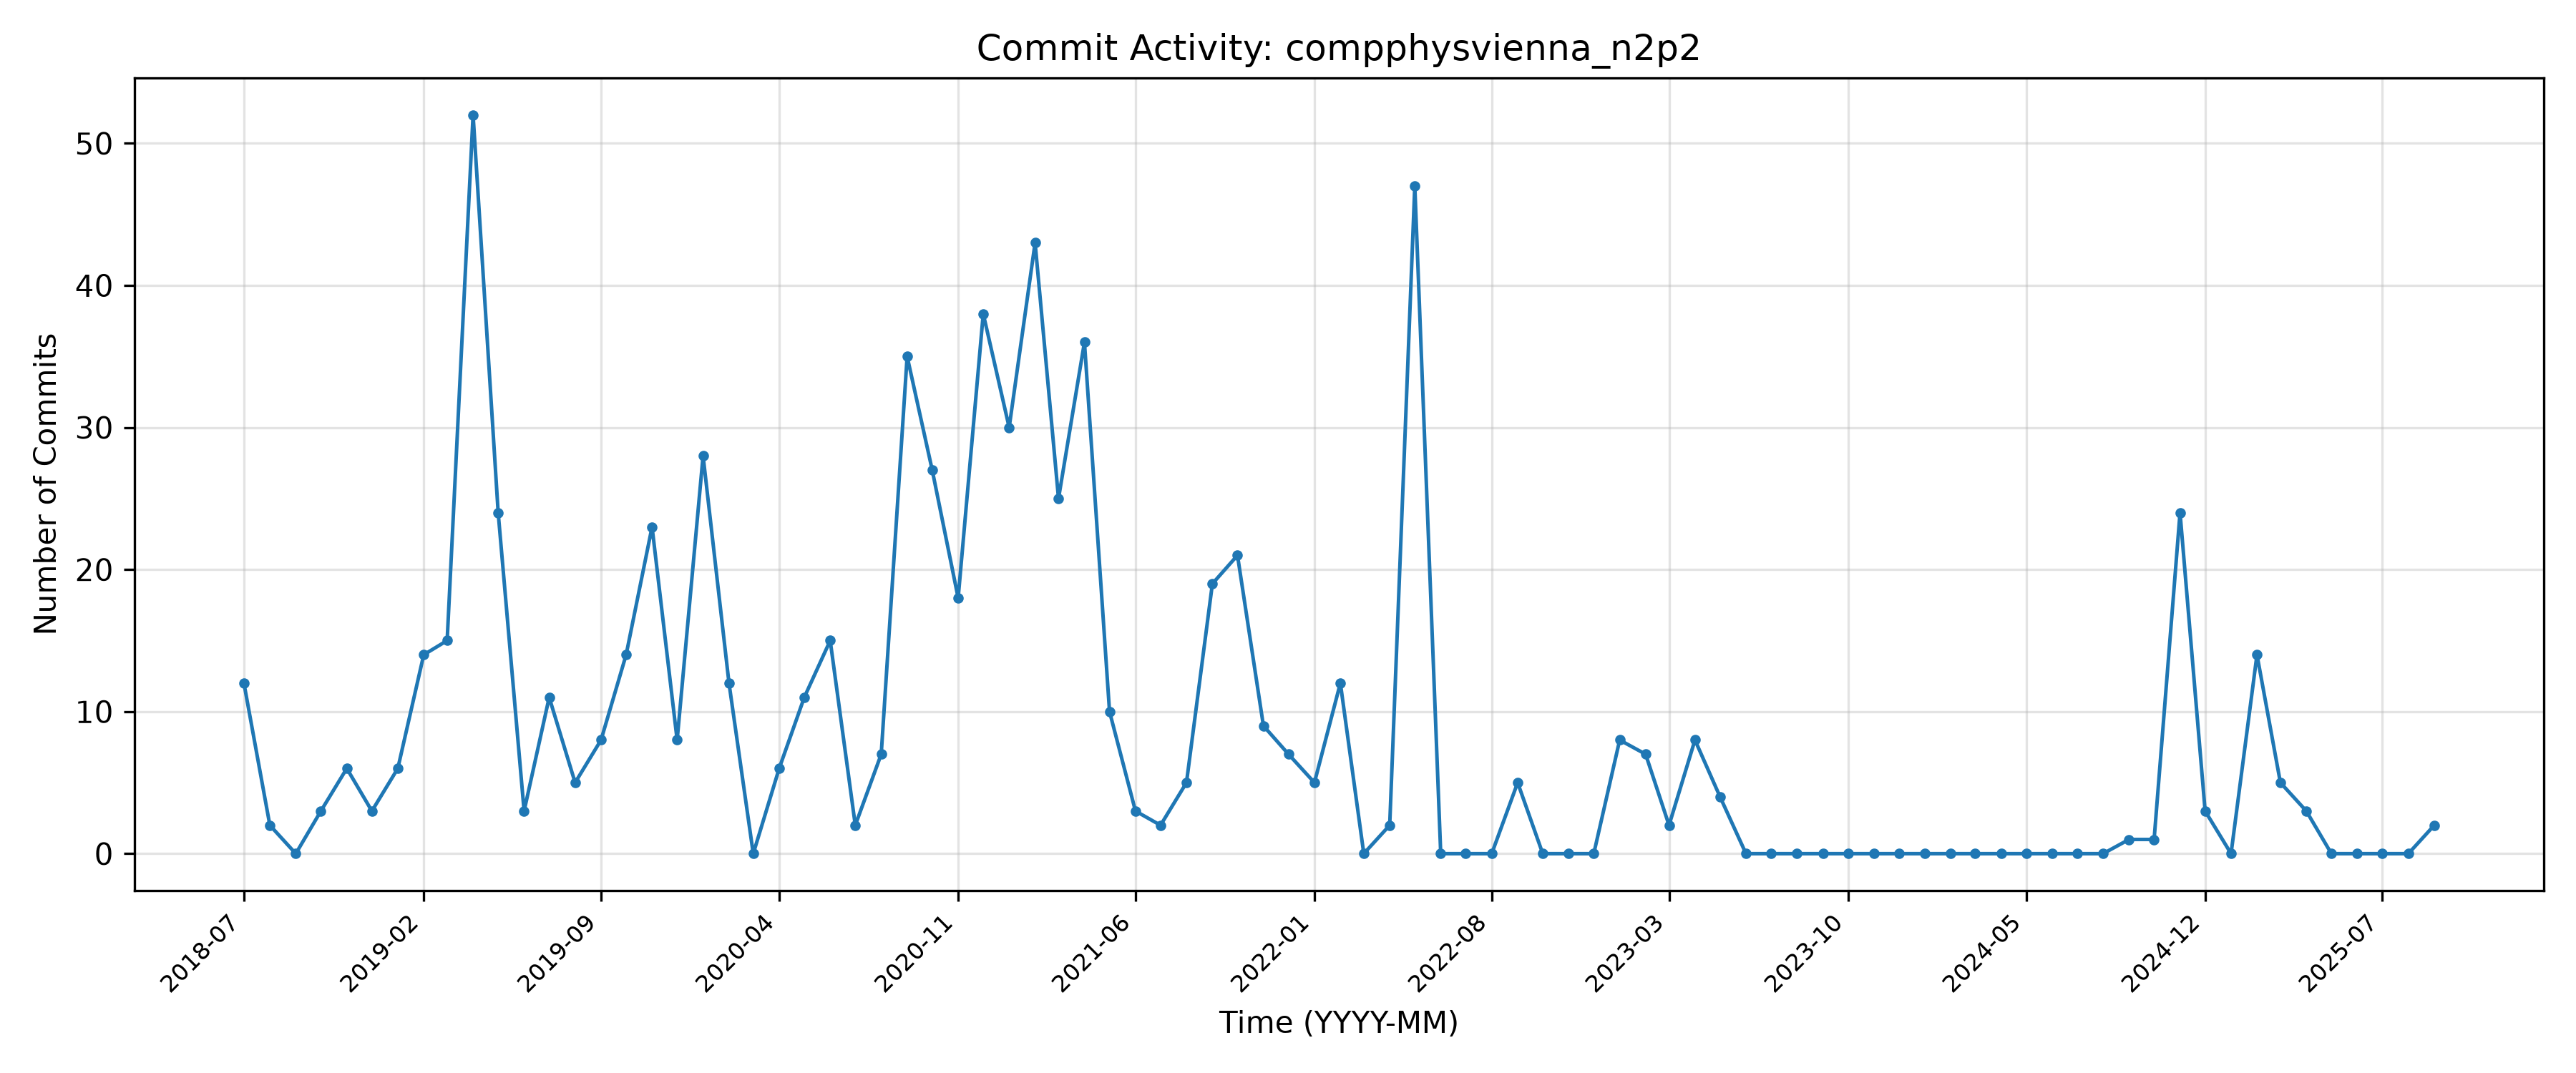

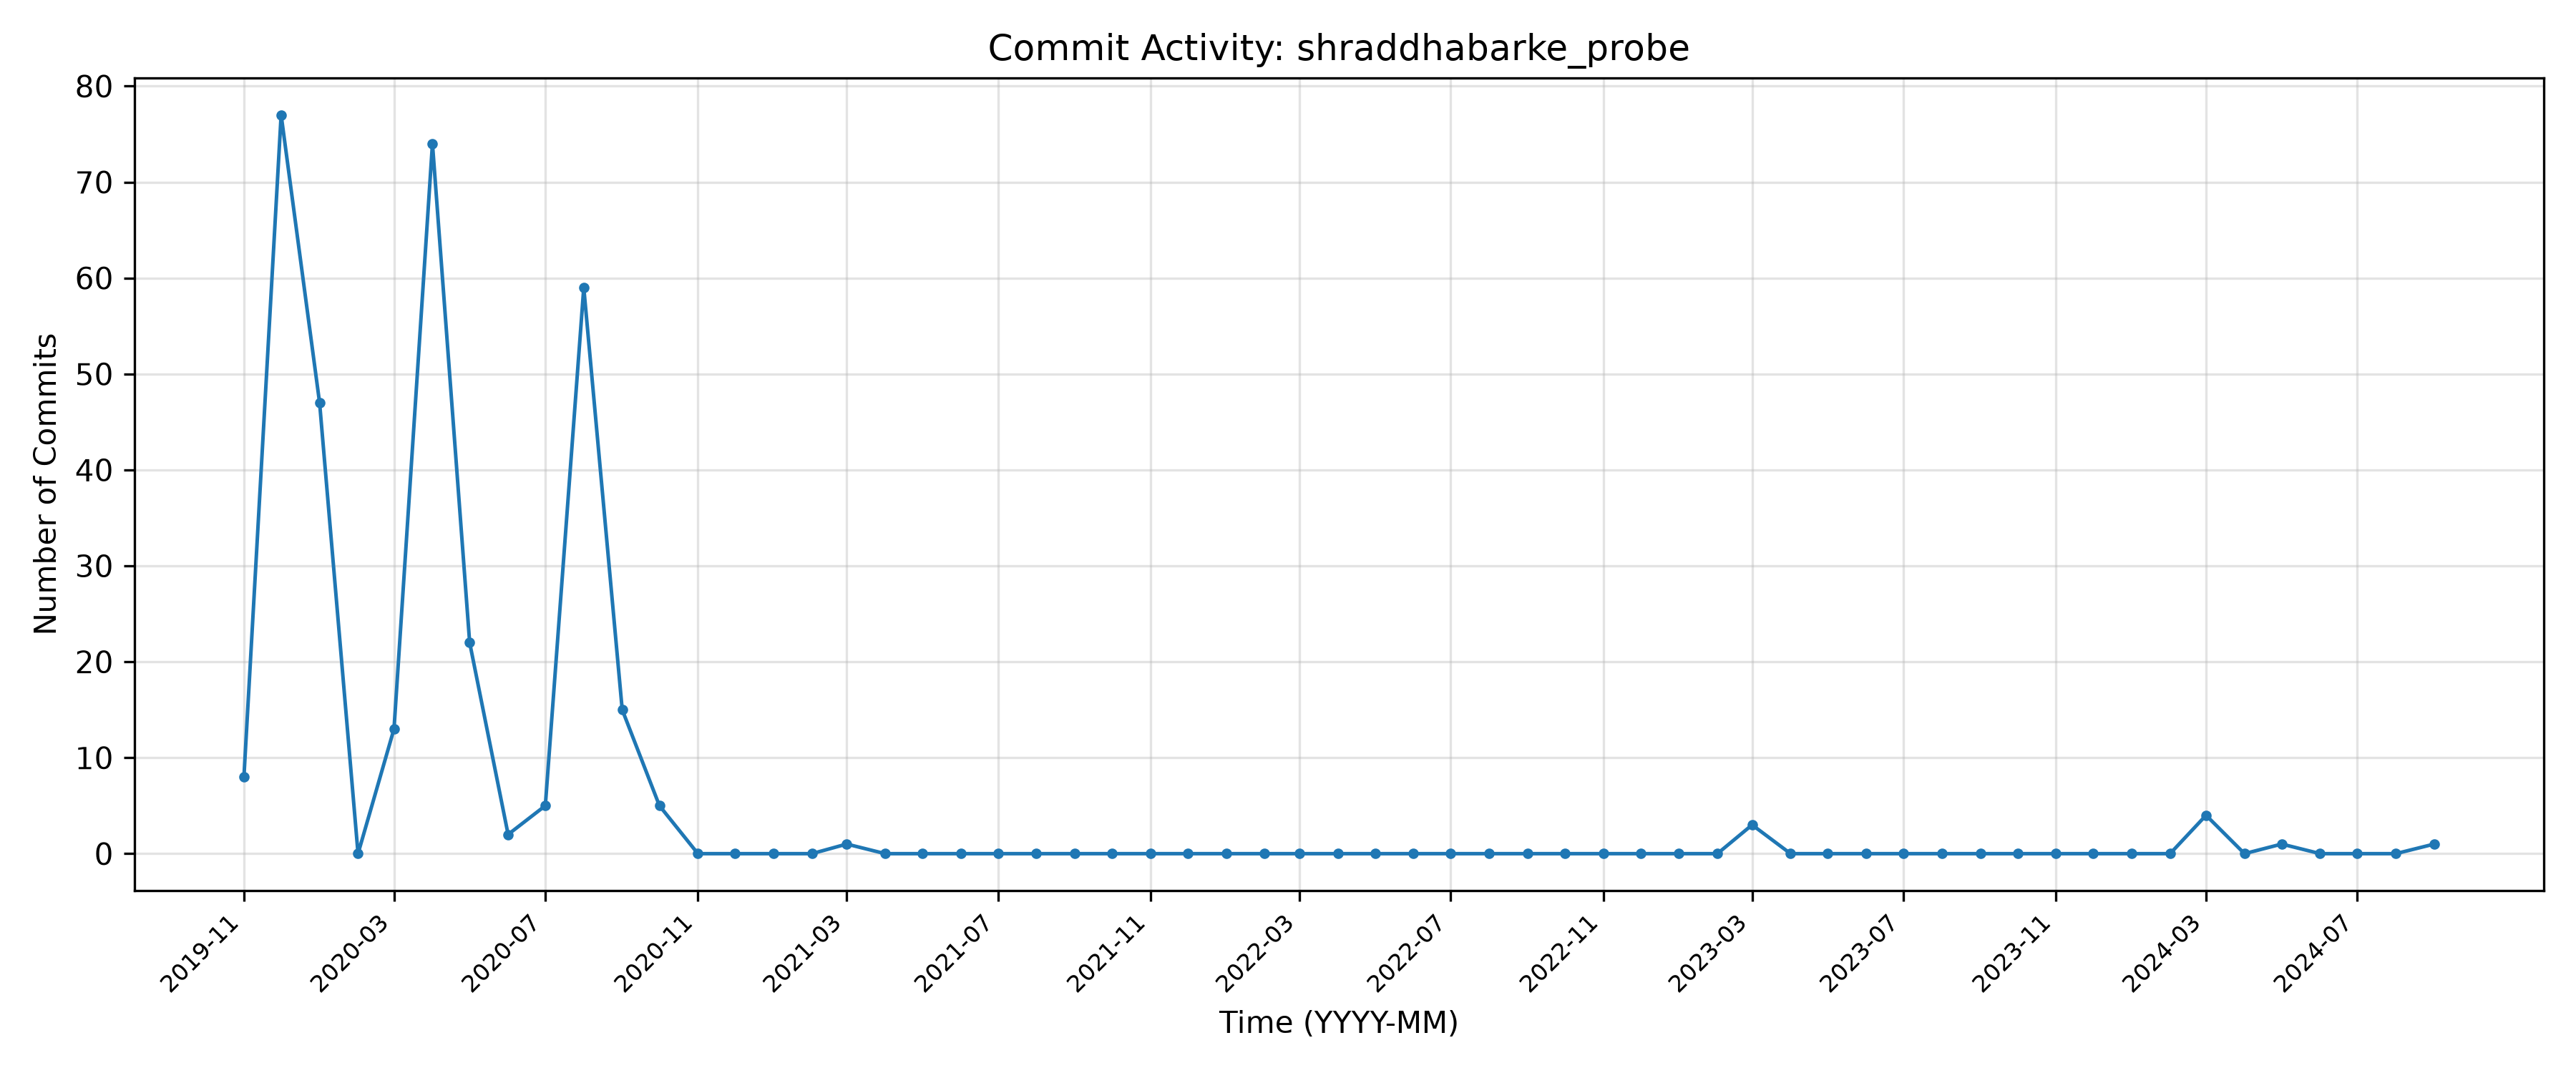

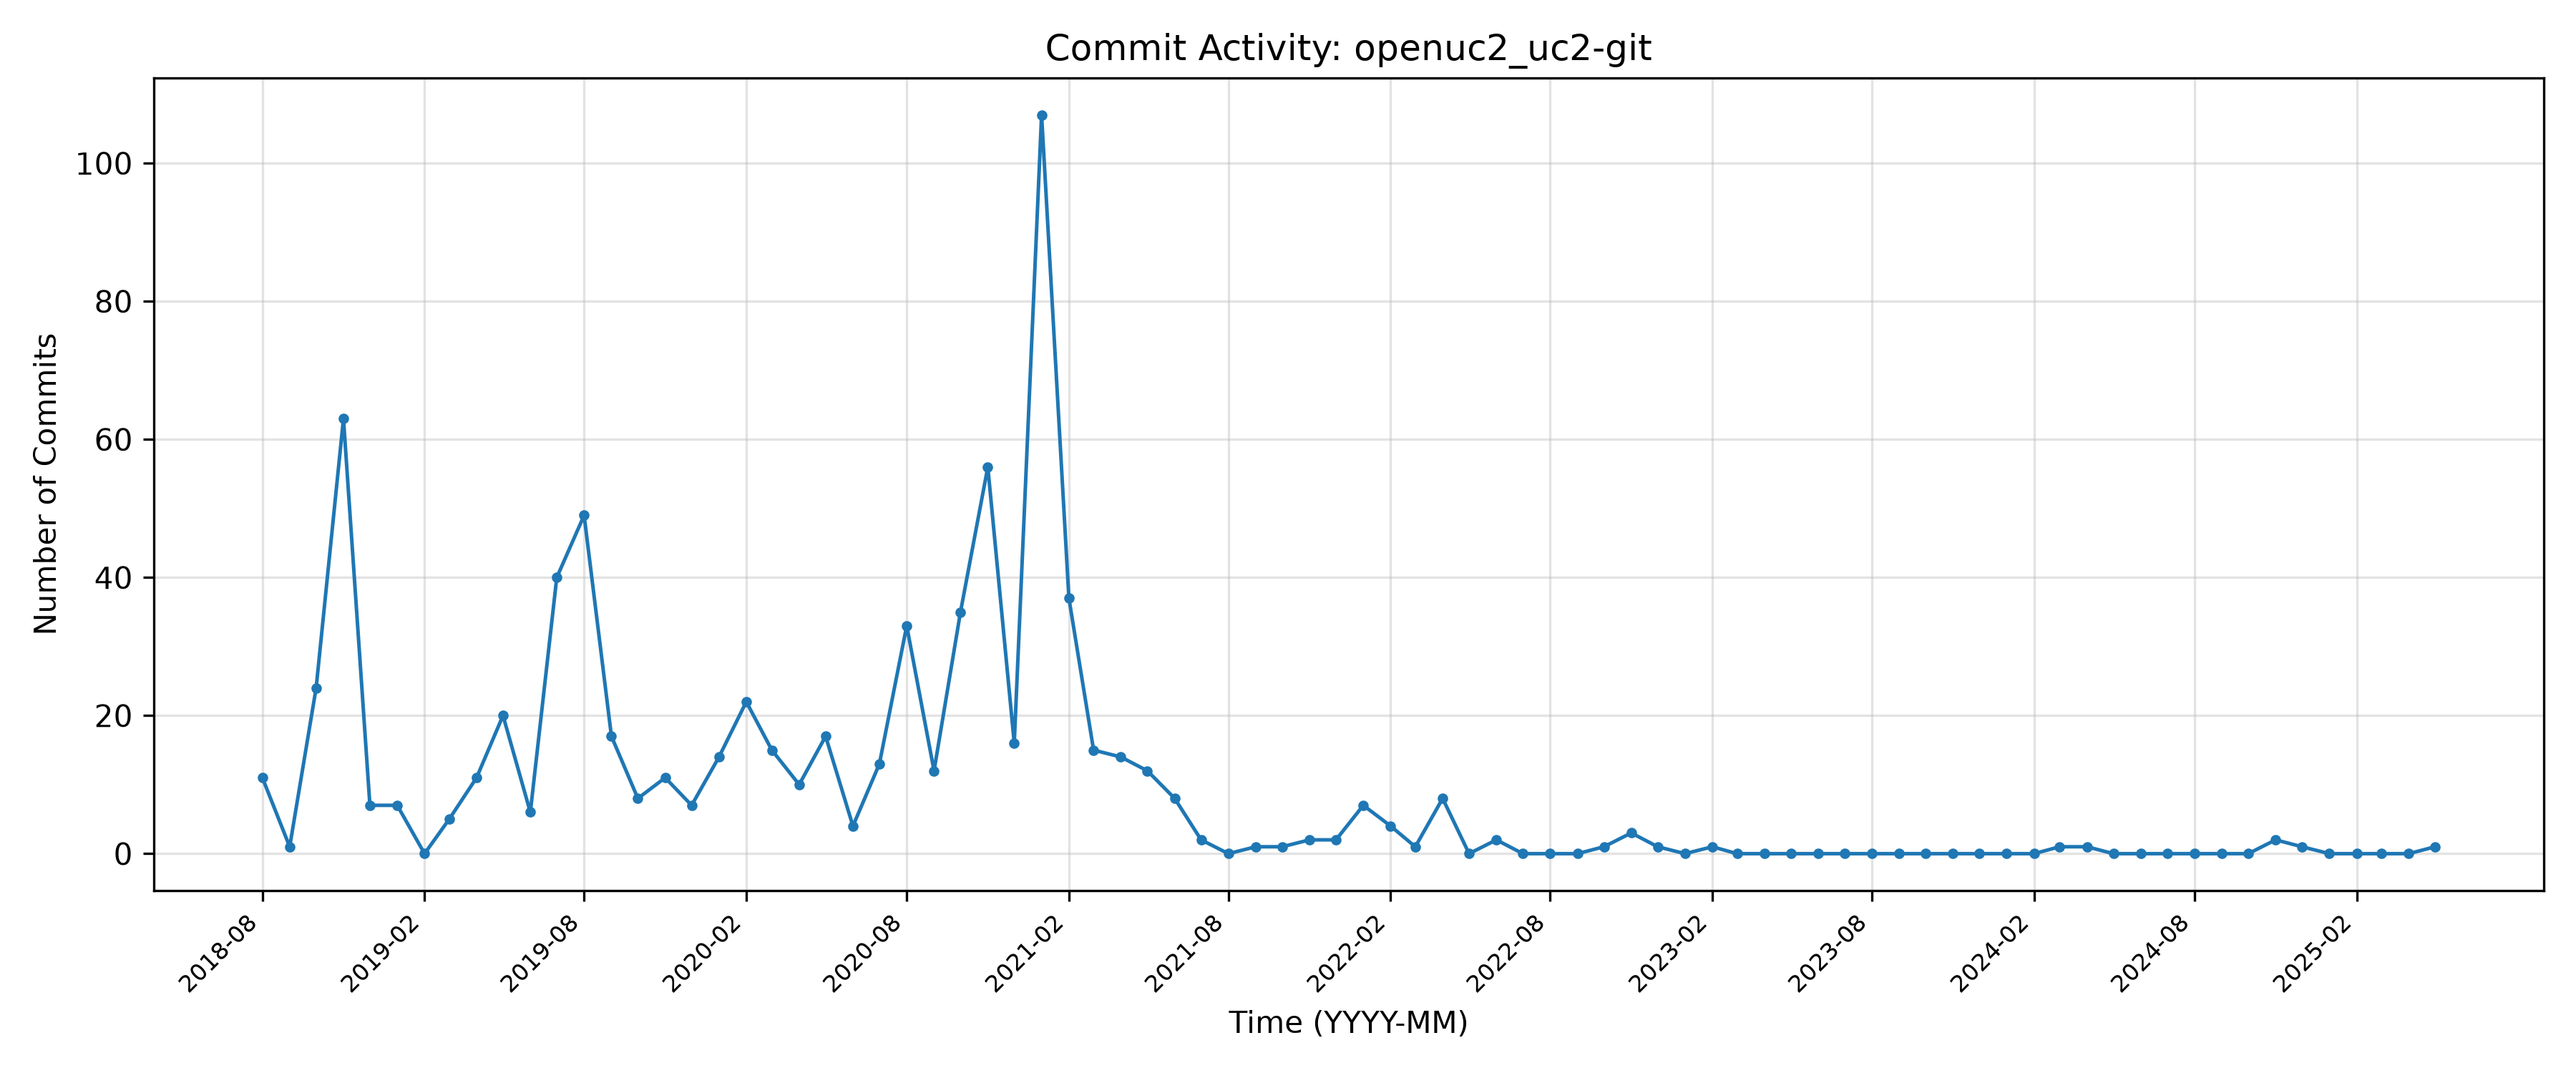

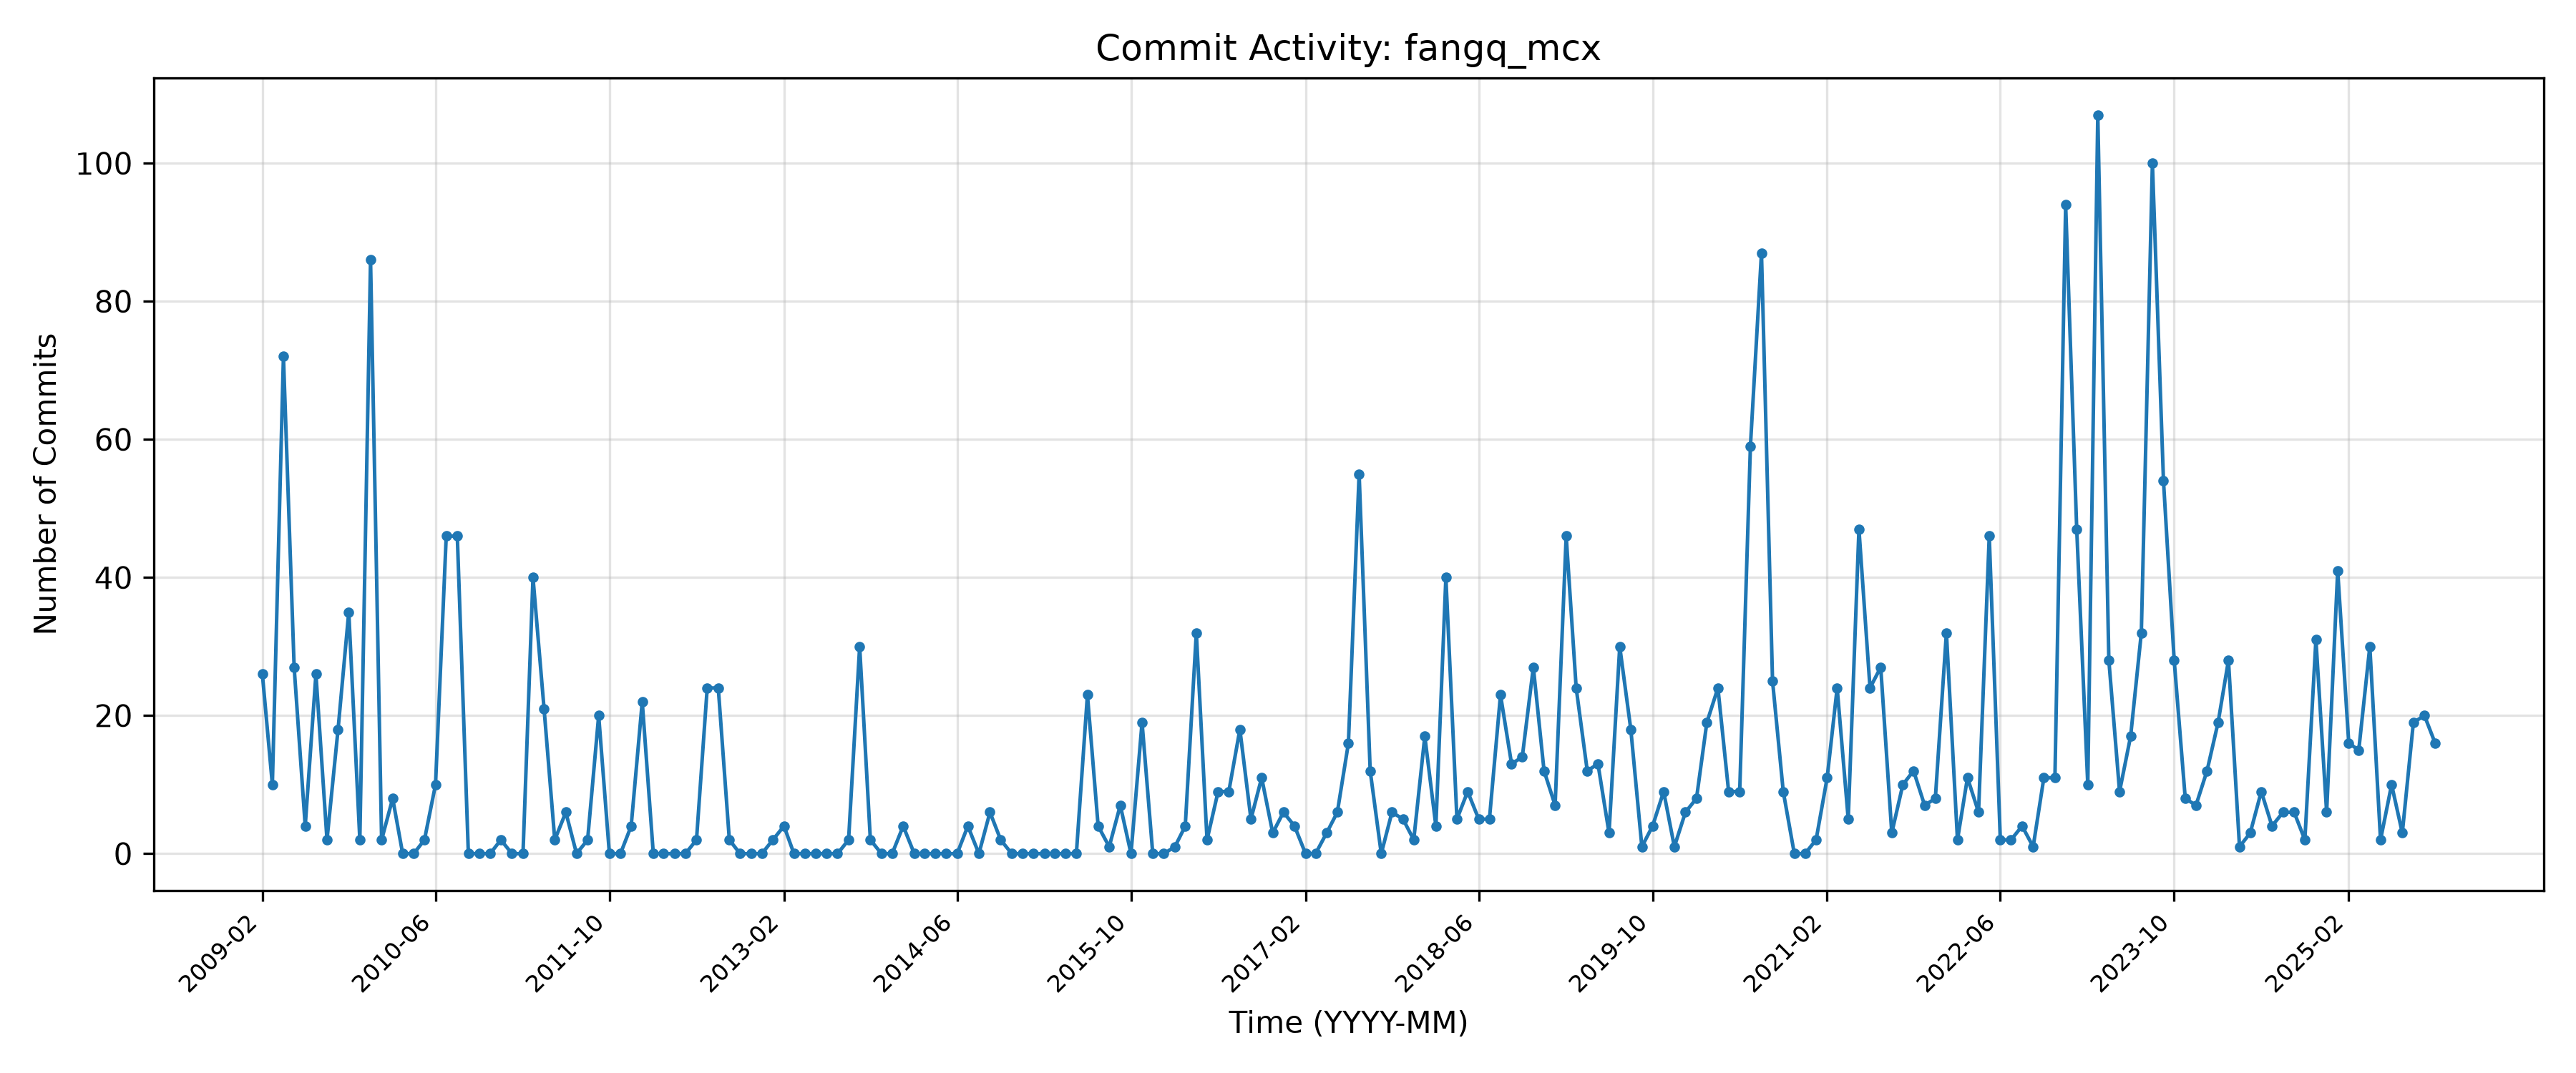

,Project,LongestGapStart,LongestGapEnd,LongestGapLength,NumberOfGapsInTimeline
0,nansencenter_dapper,2020-04,2020-07,4,3
1,quantumblacklabs_kedro-viz,2018-07,2018-08,2,0
2,biod_sambamba,2023-09,2024-06,10,5
3,hungpham2511_toppra,2024-02,2024-12,11,4
4,bioimagesuiteweb_bisweb,2024-05,2024-12,8,3
5,carloscinelli_sensemakr,2022-12,2023-10,11,6
6,compphysvienna_n2p2,2023-06,2024-08,15,4
7,shraddhabarke_probe,2021-04,2023-02,23,4
8,openuc2_uc2-git,2023-03,2024-02,12,4
9,fangq_mcx,2014-11,2015-05,7,6


In [4]:
monthly_data = {}
gap_rows = []

for prj in projects:
    df1 = df[df["project"] == prj].copy()
    monthly = make_monthly(df1)
    monthly_data[prj] = monthly
    monthly.to_csv(f"spate198_commits_timeseries_{prj}.csv", sep=";", index=False)

    plot_data = monthly.copy()
    plot_data["date"] = pd.to_datetime(plot_data["Month"], format="%Y-%m")
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(plot_data["date"], plot_data["#Commits"], marker="o", markersize=2.5, linewidth=1.2)
    ax.set_xlabel("Time (YYYY-MM)")
    ax.set_ylabel("Number of Commits")
    ax.set_title("Commit Activity: " + prj)
    ax.grid(True, alpha=0.35)
    step = max(1, len(plot_data) // 12)
    ax.set_xticks(plot_data["date"].iloc[::step])
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    plt.tight_layout()
    plt.savefig(f"spate198_timeseries_{prj}.png", dpi=300)
    display(Image(filename=f"spate198_timeseries_{prj}.png"))
    plt.close()

    gaps = find_gaps(monthly)
    longest = max(gaps, key=lambda x: x[2])
    gap_rows.append([prj, *longest, sum(length >= 3 for _, _, length in gaps)])

gap_table = pd.DataFrame(gap_rows, columns=["Project", "LongestGapStart", "LongestGapEnd", "LongestGapLength", "NumberOfGapsInTimeline"])
gap_table

## Interpretation

- **nansencenter_dapper:** This repository has an irregular history. It includes 3 gaps of at least 3 months. The longest gap was from April 2020 through July 2020. Work resumed in August 2020 with Ikeda updates, packaging changes, warning fixes, and updated development requirements.

- **quantumblacklabs_kedro-viz:** Kedro-Viz has a rising activity pattern and no gaps of at least 3 months. Its longest zero-commit period was July through August 2018, which lasted 2 months. Work resumed in September 2018. During September and October, CarbonViz was renamed KernelViz and work was done on charts, synchronization, packaging, and error handling.

- **biod_sambamba:** Sambamba has a declining activity pattern. It contains 5 gaps of at least 3 months. The longest gap lasted from September 2023 through June 2024. Work resumed in July 2024 with a compatibility contribution that compiled the binary with LDC 1.38.0. Further work in December 2024 addressed Makefile, Guix and upstream compatibility, and compiler-warning issues.

- **hungpham2511_toppra:** TOPPRA has a declining activity pattern and 4 gaps of at least 3 months. The longest gap lasted from February through December 2024. Work resumed in January 2025 with solver fixes, NumPy 2.0 and Cython compatibility, CI updates, and documentation for the new PyPI source archive in pull request 259.

- **bioimagesuiteweb_bisweb:** BISWEB has a declining activity pattern and 3 gaps of at least 3 months. The longest gap lasted from May through December 2024. Work resumed in January 2025 with a new script and a typo fix. Automated dependency merges followed in March 2025.

- **carloscinelli_sensemakr:** Sensemakr has a declining activity pattern and 6 gaps of at least 3 months. The longest gap lasted from December 2022 through October 2023. Work resumed in November 2023 with t-dagger and XRV calculations, documentation, README changes, and numerical-stability improvements.

- **compphysvienna_n2p2:** N2P2 has a declining activity pattern and 4 gaps of at least 3 months. The longest gap lasted from June 2023 through August 2024. Work resumed in September 2024 with a production predictor for 4G-HDNNP. Later work added CMake support, bug fixes, and the updated LAMMPS and Cython 3 interface from pull request 188.

- **shraddhabarke_probe:** Probe has a declining activity pattern and 4 gaps of at least 3 months. The longest gap lasted from April 2021 through February 2023. Work resumed in March 2023 when Probe was migrated to Scala 3 and current dependencies. Later work included evaluation and PCFG changes for the paper.

- **openuc2_uc2-git:** UC2-GIT has a declining activity pattern and 4 gaps of at least 3 months. The longest gap lasted from March 2023 through February 2024. Work resumed in March 2024 when Robert Haase submitted a broken-link fix in pull request 109. The maintainer merged the fix and later added files and README updates.

- **fangq_mcx:** MCX has a U-shaped activity pattern and 6 gaps of at least 3 months. The longest gap lasted from November 2014 through May 2015. Work resumed in June 2015 with seed replay, GPU querying, CUDA 6.5 compatibility, and multiple-GPU support.


# Part 3.1: Examine Commits Before and After the Gap

For each project, this section selects the last 10 commits before the longest gap and the first 10 after it, or every available commit when fewer than 10 exist.

In [5]:
gap_commits = []
for row in gap_table.itertuples(index=False):
    project_df = df[df["project"] == row.Project].sort_values(["datetime", "commit"])
    gap_start = pd.Period(row.LongestGapStart, freq="M").start_time.tz_localize("UTC")
    after_gap = (pd.Period(row.LongestGapEnd, freq="M") + 1).start_time.tz_localize("UTC")
    pre = project_df[project_df["datetime"] < gap_start].tail(10).copy()
    post = project_df[project_df["datetime"] >= after_gap].head(10).copy()
    for label, selected in [("pre", pre), ("post", post)]:
        selected = selected[["project", "commit", "author", "time", "message"]].copy()
        selected.insert(0, "pre/post", label)
        gap_commits.append(selected)

gap_commits = pd.concat(gap_commits, ignore_index=True)
gap_commits.columns = ["pre/post", "project_wocid", "commit_sha1", "author", "time", "commit message"]
gap_commits.to_csv("spate198_project_gap_commits.csv", sep=";", index=False)
gap_commits.groupby(["project_wocid", "pre/post"]).size()

project_wocid               pre/post
biod_sambamba               post         7
                            pre         10
bioimagesuiteweb_bisweb     post         5
                            pre         10
carloscinelli_sensemakr     post        10
                            pre         10
compphysvienna_n2p2         post        10
                            pre         10
fangq_mcx                   post        10
                            pre         10
hungpham2511_toppra         post        10
                            pre         10
nansencenter_dapper         post        10
                            pre         10
openuc2_uc2-git             post         6
                            pre         10
quantumblacklabs_kedro-viz  post        10
                            pre         10
shraddhabarke_probe         post         9
                            pre         10
dtype: int64

## Part 3.1: Themes Before and After the Gap

The two main themes were selected after reading the commit messages saved in the gap-commit file.

In [6]:
themes = {'nansencenter_dapper': ('Feature development:Bug fixes', 'Feature development:Bug fixes', 'Documentation updates:Bug fixes'), 'quantumblacklabs_kedro-viz': ('Feature development:Bug fixes', 'Feature development:Bug fixes', 'Automated bot contributions:Feature development'), 'biod_sambamba': ('Bug fixes:Dependency updates', 'Dependency updates:Bug fixes', 'Dependency updates:Bug fixes'), 'hungpham2511_toppra': ('Bug fixes:Documentation updates', 'Dependency updates:Bug fixes', 'Dependency updates:Bug fixes'), 'bioimagesuiteweb_bisweb': ('Feature development:Automated bot contributions', 'Feature development:Automated bot contributions', 'Feature development:Automated bot contributions'), 'carloscinelli_sensemakr': ('Bug fixes:Documentation updates', 'Feature development:Documentation updates', 'Release:Bug fixes'), 'compphysvienna_n2p2': ('Feature development:Dependency updates', 'Feature development:Dependency updates', 'Bug fixes:Feature development'), 'shraddhabarke_probe': ('Other:Documentation updates', 'Feature development:Dependency updates', 'Feature development:Documentation updates'), 'openuc2_uc2-git': ('Documentation updates:Feature development', 'Documentation updates:Feature development', 'Documentation updates:Feature development'), 'fangq_mcx': ('Bug fixes:Release', 'Feature development:Dependency updates', 'Release:Documentation updates')}
theme_rows = [{"Project": project, "BeforeThemes": themes[project][0], "AfterThemes": themes[project][1]} for project in projects]
pd.DataFrame(theme_rows)

,Project,BeforeThemes,AfterThemes
0,nansencenter_dapper,Feature development:Bug fixes,Feature development:Bug fixes
1,quantumblacklabs_kedro-viz,Feature development:Bug fixes,Feature development:Bug fixes
2,biod_sambamba,Bug fixes:Dependency updates,Dependency updates:Bug fixes
3,hungpham2511_toppra,Bug fixes:Documentation updates,Dependency updates:Bug fixes
4,bioimagesuiteweb_bisweb,Feature development:Automated bot contributions,Feature development:Automated bot contributions
5,carloscinelli_sensemakr,Bug fixes:Documentation updates,Feature development:Documentation updates
6,compphysvienna_n2p2,Feature development:Dependency updates,Feature development:Dependency updates
7,shraddhabarke_probe,Other:Documentation updates,Feature development:Dependency updates
8,openuc2_uc2-git,Documentation updates:Feature development,Documentation updates:Feature development
9,fangq_mcx,Bug fixes:Release,Feature development:Dependency updates


# Part 3.2: Interpret the Gap

This section records the evidence-based gap hypothesis, whether and why activity returned, who returned, current status under the assignment's cutoff, recent themes, and a short note for each project. When no maintainer stated a cause, the explanation is labeled as a hypothesis.

## Compare contributors before and after the longest gap

In [7]:
author_rows = []
for project in projects:
    selected = gap_commits[gap_commits["project_wocid"] == project]
    pre_authors = sorted(selected.loc[selected["pre/post"] == "pre", "author"].unique())
    post_authors = sorted(selected.loc[selected["pre/post"] == "post", "author"].unique())
    author_rows.append({"Project": project, "PreAuthors": pre_authors, "PostAuthors": post_authors})

author_comparison = pd.DataFrame(author_rows)
author_comparison

,Project,PreAuthors,PostAuthors
0,nansencenter_dapper,"[Patrick <patrick.n.raanes@gmail.com>, patrick...",[patricknraanes <patrick.n.raanes@gmail.com>]
1,quantumblacklabs_kedro-viz,"[Ivan Danov <idanov@users.noreply.github.com>,...","[Ivan Danov <idanov@users.noreply.github.com>,..."
2,biod_sambamba,"[Pjotr Prins <pjotr.public01@thebird.nl>, Rui ...",[Cornelius Roemer <cornelius.roemer@gmail.com>...
3,hungpham2511_toppra,"[Chenna Kautilya <chenna@outlook.com>, Chenna ...","[Hung Pham <hungpham2511@gmail.com>, Maxim Skr..."
4,bioimagesuiteweb_bisweb,[Xenios Papademetris <xenophon.papademetris@ya...,[Xenios Papademetris <xpapademetris@gmail.com>...
5,carloscinelli_sensemakr,"[Carlos Cinelli <carloscinelli@hotmail.com>, C...",[Carlos Cinelli <carloslkcinelli@gmail.com>]
6,compphysvienna_n2p2,[Andreas Singraber <andreas.singraber@vasp.at>...,"[Andreas Singraber <andreas.singraber@gmx.at>,..."
7,shraddhabarke_probe,[Shraddha Barke <31306549+shraddhabarke@users....,[Shraddha Barke <sbarke@eng.ucsd.edu>]
8,openuc2_uc2-git,"[Benedict Diederich <bene.d@gmx.de>, Eda Bingö...","[Benedict Diederich <bene.d@gmx.de>, Robert Ha..."
9,fangq_mcx,"[Qianqian Fang <fangqq@gmail.com>, fangq <fang...",[Qianqian Fang <fangqq@gmail.com>]


## Select recent commits and apply the current-status cutoff

Recent themes use the last 10 available commits at or before each project's GitHub date. Current status uses the assignment's April 1, 2025 cutoff.

In [8]:
github_stats = {'nansencenter_dapper': (415, 132, '2026-06-26T11:44:41Z'), 'quantumblacklabs_kedro-viz': (761, 126, '2026-09-15T14:46:21Z'), 'biod_sambamba': (613, 103, '2024-12-22T10:07:47Z'), 'hungpham2511_toppra': (929, 212, '2026-08-28T05:00:11Z'), 'bioimagesuiteweb_bisweb': (86, 36, '2026-09-10T14:03:45Z'), 'carloscinelli_sensemakr': (100, 17, '2026-08-13T22:12:33Z'), 'compphysvienna_n2p2': (244, 95, '2025-03-17T11:03:50Z'), 'shraddhabarke_probe': (3, 2, '2024-09-11T13:58:56Z'), 'openuc2_uc2-git': (533, 76, '2026-08-09T17:25:59Z'), 'fangq_mcx': (193, 96, '2026-09-18T17:17:35Z')}
recent_frames = []
for project in projects:
    github_date = pd.Timestamp(github_stats[project][2])
    latest = df[(df["project"] == project) & (df["datetime"] <= github_date)].sort_values(["datetime", "commit"]).tail(10).copy()
    recent_frames.append(latest)

recent_commits = pd.concat(recent_frames, ignore_index=True)
recent_commits.groupby("project").size().rename("commits reviewed")

project
biod_sambamba                 10
bioimagesuiteweb_bisweb       10
carloscinelli_sensemakr       10
compphysvienna_n2p2           10
fangq_mcx                     10
hungpham2511_toppra           10
nansencenter_dapper           10
openuc2_uc2-git               10
quantumblacklabs_kedro-viz    10
shraddhabarke_probe           10
Name: commits reviewed, dtype: int64

In [9]:
activity = {'nansencenter_dapper': 'irregular', 'quantumblacklabs_kedro-viz': 'rising', 'biod_sambamba': 'declining', 'hungpham2511_toppra': 'declining', 'bioimagesuiteweb_bisweb': 'declining', 'carloscinelli_sensemakr': 'declining', 'compphysvienna_n2p2': 'declining', 'shraddhabarke_probe': 'declining', 'openuc2_uc2-git': 'declining', 'fangq_mcx': 'U-shaped'}
reasons = {'nansencenter_dapper': {'reason': 'A four-month pause followed a March 2020 batch that added the Ikeda map and closed issue #11. No commit or issue states a shutdown, so this looks like a normal pause in a project developed in bursts.', 'recovered': 'Yes', 'why': 'Work restarted in August 2020 with Ikeda updates, packaging changes, warning fixes, and development requirements.', 'who': 'The same maintainer, Patrick Raanes, made the commits immediately before and after the gap.'}, 'quantumblacklabs_kedro-viz': {'reason': 'N/A active Project', 'recovered': 'Not applicable', 'why': 'Not applicable - there is no inactivity gap of at least three months.', 'who': 'Not applicable - no recovery was required; existing contributors Ivan Danov and Richard Westenra continued the work.'}, 'biod_sambamba': {'reason': 'The ten-month gap came after an August 2023 CI cleanup. PR #508 says Travis was removed because the project had moved to GitHub Actions, so the available evidence points to a maintenance lull after build-system work rather than a declared shutdown.', 'recovered': 'Yes', 'why': 'A compatibility contribution compiled the binary with LDC 1.38.0 in July 2024 (PR #518), followed by Makefile, Guix, upstream, and compiler-warning fixes in December.', 'who': 'New contributor Cornelius Roemer supplied the first post-gap change; maintainer Pjotr Prins merged it and later continued the maintenance work.'}, 'hungpham2511_toppra': {'reason': 'The eleven-month gap followed January 2024 fixes for numerical bounds and C++ initialization. PR #247 was opened before the gap and merged after it, while PR #259 handled NumPy 2.0 compatibility. This suggests a maintenance and compatibility backlog, but the exact cause was not stated.', 'recovered': 'Yes', 'why': 'The project resumed with solver fixes, NumPy 2.0/Cython compatibility, CI updates, and a new PyPI source archive documented in PR #259.', 'who': "New contributors wxflamy and Zachary Kingston helped restart work; Maxim Skripnik's earlier fixes were merged, and maintainer Hung Pham returned for CI and release work."}, 'bioimagesuiteweb_bisweb': {'reason': 'The eight-month gap followed March-April 2024 spectral-clustering pipeline work and automated dependency merges. There is no explicit abandonment message, so the safest explanation is a pause between maintainer development batches.', 'recovered': 'Yes', 'why': 'The maintainer returned in January 2025 to add a script and fix a typo, and automated dependency merges followed in March.', 'who': 'Existing maintainer Xenios Papademetris restarted the human work; Dependabot supplied later automated activity.'}, 'carloscinelli_sensemakr': {'reason': 'The eleven-month gap followed 2022 fixes, website work, and integration of fixest support from PR #53. Nothing in the nearby messages declares the project inactive, so it most likely reflects a pause between research and package-development batches.', 'recovered': 'Yes', 'why': 'Carlos Cinelli resumed in November 2023 with t-dagger and XRV calculations, documentation, README changes, and numerical-stability work.', 'who': 'The same maintainer, Carlos Cinelli, made the first post-gap commits.'}, 'compphysvienna_n2p2': {'reason': 'The fifteen-month gap followed 4G-HDNNP training work, Eigen/LAMMPS build fixes, and pynnp changes in spring 2023. The record does not state a formal hiatus, but the restart around production 4G support and a modern build interface suggests a long development pause while larger changes were prepared.', 'recovered': 'Yes', 'why': "Work resumed with a production 4G-HDNNP predictor, CMake support, bug fixes, and PR #188's updated LAMMPS and Cython 3 interface.", 'who': 'New contributors ekocer and Amro Dodin joined the restart, while existing maintainer Andreas Singraber returned for the LAMMPS interface.'}, 'shraddhabarke_probe': {'reason': 'The twenty-three-month gap began just after the Probe paper was added in March 2021. The project is a small research codebase, so the evidence suggests a pause after the paper milestone rather than an announced cancellation.', 'recovered': 'Yes', 'why': 'Work restarted in March 2023 to migrate Probe to Scala 3 and current dependencies, then continued with evaluation and PCFG changes for the paper.', 'who': 'Shraddha Barke made the commits on both sides of the gap, using a newer institutional email afterward.'}, 'openuc2_uc2-git': {'reason': 'The twelve-month gap followed mostly README and broken-link maintenance through February 2023. No message announces abandonment; the pattern is consistent with a documentation repository that changes only when hardware or instructions need updates.', 'recovered': 'Yes', 'why': 'Robert Haase submitted a broken-link fix in March 2024 (PR #109), after which the maintainer merged it and added files and README updates.', 'who': 'New contributor Robert Haase supplied the first change, and existing maintainer Benedict Diederich continued the recovery.'}, 'fangq_mcx': {'reason': 'The seven-month gap followed version 0.9.7-2 documentation, post-release cleanup, a voxel-scaling fix, and an RNG-interface update. The sequence looks like a release-cycle pause while the next GPU features were prepared.', 'recovered': 'Yes', 'why': 'June 2015 commits added seed replay, GPU querying, CUDA 6.5 compatibility, and multiple-GPU support.', 'who': 'The same lead maintainer, Qianqian Fang, drove the work before and after the gap.'}}
notes = {'nansencenter_dapper': 'DAPPER has an irregular history with 3 gaps of at least three months. The longest gap was April through July 2020. The same maintainer resumed in August with Ikeda, packaging, and warning fixes, but I found no stated reason for the pause.', 'quantumblacklabs_kedro-viz': 'Kedro-Viz has a rising pattern and no gap of at least three months. Its longest zero-commit run was only July-August 2018, followed by the KernelViz rename and new chart and synchronization work. This looks like a short early-development pause.', 'biod_sambamba': 'Sambamba has a declining pattern with 5 long gaps. Its ten-month gap followed the move from Travis to GitHub Actions, and work returned with LDC 1.38.0 and build fixes. The evidence supports a maintenance lull, although no maintainer stated the exact reason.', 'hungpham2511_toppra': 'TOPPRA has a declining pattern with 4 long gaps, the largest lasting eleven months in 2024. Work returned with solver, NumPy 2.0/Cython, CI, and packaging updates. The pull requests suggest a compatibility backlog, but they do not state the exact reason for the gap.', 'bioimagesuiteweb_bisweb': 'BISWEB has a declining pattern with 3 long gaps. After the eight-month gap, the maintainer added a script and fixed a typo, followed by Dependabot merges. I found no announcement explaining the pause.', 'carloscinelli_sensemakr': 'Sensemakr has a declining pattern with 6 long gaps. The same maintainer returned after the eleven-month gap with t-dagger, XRV, documentation, and stability work. The messages show what restarted the work but do not give a reason for the pause.', 'compphysvienna_n2p2': 'N2P2 has a declining pattern with 4 long gaps, including a fifteen-month gap. New and existing contributors returned with a production 4G-HDNNP predictor, CMake support, and an updated LAMMPS interface. The cause of the long development pause was not stated.', 'shraddhabarke_probe': 'Probe has a declining pattern with 4 long gaps. Its twenty-three-month gap began after the paper was added, and the same author later migrated the project to Scala 3 and continued paper-related work. This fits a research-project pause, but that reason is still an inference.', 'openuc2_uc2-git': 'UC2-GIT has a declining pattern with 4 long gaps. After the twelve-month gap, a new contributor fixed a broken link and the maintainer added files and README updates. The repository appears to be updated when documentation or hardware instructions need changes.', 'fangq_mcx': 'MCX has a U-shaped history with 6 long gaps. The same maintainer returned after the seven-month gap with seed replay, GPU querying, CUDA 6.5, and multi-GPU support. The timing resembles a release-cycle pause, although the commits do not prove that cause.'}
stats_rows = []
for gap in gap_table.itertuples(index=False):
    project_df = df[df["project"] == gap.Project]
    after_gap = (pd.Period(gap.LongestGapEnd, freq="M") + 1).start_time.tz_localize("UTC")
    stars, forks, last_date = github_stats[gap.Project]
    before, after, recent = themes[gap.Project]
    reason = reasons[gap.Project]
    status = "Inactive" if pd.Timestamp(last_date) < pd.Timestamp("2025-04-01T00:00:00Z") else "Active"
    note = notes[gap.Project]
    stats_rows.append({"Project": gap.Project, "ncommits": len(project_df), "nauthors": project_df["author"].nunique(),
        "from": int(project_df["time"].min()), "to": int(project_df["time"].max()), "nstars": stars, "nforks": forks,
        "lastGHCommitDate": last_date, "LongestGapStart": gap.LongestGapStart, "LongestGapEnd": gap.LongestGapEnd,
        "LongestGapLength": gap.LongestGapLength, "NumCommitsAfterLastGap": int((project_df["datetime"] >= after_gap).sum()),
        "ActivityPattern": activity[gap.Project], "NumberOfGapsInTimeline": gap.NumberOfGapsInTimeline,
        "BeforeThemes": before, "AfterThemes": after, "HypothesizedGapReason": reason["reason"],
        "HasRecovered": reason["recovered"], "WhyRecovered": reason["why"], "WhoRecovered": reason["who"],
        "Currentstatus": status, "RecentThemes": recent, "Notes": note})

project_stats = pd.DataFrame(stats_rows)
project_stats.to_csv("spate198_project_stats.csv", sep=";", index=False)
project_stats[["Project", "BeforeThemes", "AfterThemes", "Currentstatus", "RecentThemes"]]

,Project,BeforeThemes,AfterThemes,Currentstatus,RecentThemes
0,nansencenter_dapper,Feature development:Bug fixes,Feature development:Bug fixes,Active,Documentation updates:Bug fixes
1,quantumblacklabs_kedro-viz,Feature development:Bug fixes,Feature development:Bug fixes,Active,Automated bot contributions:Feature development
2,biod_sambamba,Bug fixes:Dependency updates,Dependency updates:Bug fixes,Inactive,Dependency updates:Bug fixes
3,hungpham2511_toppra,Bug fixes:Documentation updates,Dependency updates:Bug fixes,Active,Dependency updates:Bug fixes
4,bioimagesuiteweb_bisweb,Feature development:Automated bot contributions,Feature development:Automated bot contributions,Active,Feature development:Automated bot contributions
5,carloscinelli_sensemakr,Bug fixes:Documentation updates,Feature development:Documentation updates,Active,Release:Bug fixes
6,compphysvienna_n2p2,Feature development:Dependency updates,Feature development:Dependency updates,Inactive,Bug fixes:Feature development
7,shraddhabarke_probe,Other:Documentation updates,Feature development:Dependency updates,Inactive,Feature development:Documentation updates
8,openuc2_uc2-git,Documentation updates:Feature development,Documentation updates:Feature development,Active,Documentation updates:Feature development
9,fangq_mcx,Bug fixes:Release,Feature development:Dependency updates,Active,Release:Documentation updates


## Part 3.2: Project Reflections

The reflections discuss the inactivity pattern, how easy or difficult the longest gap was to interpret, the likely reason for inactivity or recovery, and the supporting evidence.

In [10]:
from pathlib import Path

reflections = {'nansencenter_dapper': "# Reflection: nansencenter_dapper\n\nI found this four-month gap easy to describe but harder to explain. The March 2020 commits added the Ikeda map and closed [issue #11](https://github.com/nansencenter/DAPPER/issues/11), while the August commits made smaller Ikeda, packaging, and warning fixes. I did not find a message saying that DAPPER had been abandoned. My best reading is that this project is developed in bursts, especially because Patrick Raanes worked on both sides of the gap. DAPPER is active under the assignment's April 1, 2025 cutoff.\n", 'quantumblacklabs_kedro-viz': "# Reflection: quantumblacklabs_kedro-viz\n\nKedro-Viz was the simplest case because its longest zero-commit period was only two months. That does not meet the assignment's three-month definition of a long gap. Work returned with the CarbonViz-to-KernelViz rename and then chart, synchronization, packaging, and error-handling changes. Ivan Danov and Richard Westenra were already involved before the pause, so there was no clear contributor turnover. I see this as a short pause during early development, not a project shutdown.\n", 'biod_sambamba': "# Reflection: biod_sambamba\n\nSambamba's chart declines and contains five gaps of at least three months. Before the longest gap, [PR #508](https://github.com/biod/sambamba/pull/508) removed Travis because the project had moved to GitHub Actions. The first later contribution, [PR #518](https://github.com/biod/sambamba/pull/518), added LDC 1.38.0 compatibility, and more build fixes followed. The gap was hard to interpret; it looks like a maintenance lull, but I could not find a statement giving the exact reason. A new contributor, Cornelius Roemer, started the recovery, and Pjotr Prins continued it; the project is inactive under the assignment cutoff.\n", 'hungpham2511_toppra': '# Reflection: hungpham2511_toppra\n\nTOPPRA has a declining pattern and four long gaps. Its largest gap lasted from February through December 2024, and I found it hard to interpret with certainty. [PR #247](https://github.com/hungpham2511/toppra/pull/247) was opened before that gap and merged after it, while [PR #259](https://github.com/hungpham2511/toppra/pull/259) handled NumPy 2.0 and Cython compatibility. That evidence suggests a maintenance and compatibility backlog, although no one states the exact cause. New contributors helped restart the work, and the project is active under the assignment cutoff.\n', 'bioimagesuiteweb_bisweb': '# Reflection: bioimagesuiteweb_bisweb\n\nBISWEB has a declining pattern with three gaps of at least three months. The longest gap followed spectral-clustering work and automated dependency merges. In January 2025, Xenios Papademetris returned to add a script and fix a typo, and Dependabot activity followed in March. This gap was hard to interpret because I did not find an issue or commit that explains why work paused. Because the same maintainer returned, I think this was a break between work batches rather than a handoff to a new team.\n', 'carloscinelli_sensemakr': '# Reflection: carloscinelli_sensemakr\n\nSensemakr has a declining timeline and six long gaps. The eleven-month gap came after fixes, website updates, and the merge of [PR #53](https://github.com/carloscinelli/sensemakr/pull/53) for `fixest` support. Carlos Cinelli returned with t-dagger, XRV, documentation, README, and numerical-stability work. The restart was easy to identify, but the reason for the gap was hard to interpret; a pause between research and package-development work seems most likely. The project is active under the assignment cutoff.\n', 'compphysvienna_n2p2': "# Reflection: compphysvienna_n2p2\n\nN2P2's fifteen-month gap was the second-longest one in my data. Before it, the commits covered 4G-HDNNP training, build fixes, and `pynnp`; afterward, they added a production predictor and CMake support. [PR #188](https://github.com/CompPhysVienna/n2p2/pull/188) also brought an updated LAMMPS interface and Cython 3 work. The restart is clear, but the gap itself was hard to interpret because the record does not explain the delay. New contributors joined the restart, but N2P2 is inactive under the assignment's fixed cutoff date.\n", 'shraddhabarke_probe': '# Reflection: shraddhabarke_probe\n\nProbe had the longest gap in this set: April 2021 through February 2023. The last pre-gap commit added the Probe paper, and the same author later returned to migrate the project to Scala 3 and update its dependencies. Later commits again mention evaluation, PCFG work, and the paper. This gap was fairly easy to interpret because it sits between two paper-related work periods, although a post-paper pause is still only an inference. Probe is inactive under the assignment cutoff.\n', 'openuc2_uc2-git': "# Reflection: openuc2_uc2-git\n\nUC2-GIT's longest gap lasted twelve months. The surrounding commits are mainly README, file-upload, and broken-link changes rather than steady software development. Robert Haase ended the gap with [PR #109](https://github.com/openUC2/UC2-GIT/pull/109), and Benedict Diederich merged it and continued updating the repository. The gap was somewhat hard to interpret, but I think this repository is maintained when documentation or hardware instructions need changes. It is active under the assignment cutoff.\n", 'fangq_mcx': '# Reflection: fangq_mcx\n\nMCX is different from most of the other projects because its overall pattern is U-shaped. The seven-month gap came after version 0.9.7-2 documentation, bug fixes, and release cleanup. Qianqian Fang then returned with seed replay, GPU querying, CUDA 6.5 compatibility, and multi-GPU support. The gap was easy to locate but hard to explain; the timing looks like a pause between release cycles, although the messages do not prove it. MCX recovered strongly and is active under the assignment cutoff.\n'}
for project, reflection in reflections.items():
    Path(f"spate198_reflection_{project}.md").write_text(reflection, encoding="utf-8")

print(f"Created {len(reflections)} reflection files.")

Created 10 reflection files.


# Final Validation

In [11]:
assert len(projects) == 10
assert df["project"].nunique() == 10
assert len(project_stats) == 10
assert project_stats["NumberOfGapsInTimeline"].ge(0).all()
assert gap_commits.groupby(["project_wocid", "pre/post"]).size().le(10).all()
print(f"Checked {len(df):,} commits, 10 time series, 10 plots, and 10 project rows.")

Checked 29,145 commits, 10 time series, 10 plots, and 10 project rows.
